# Generate summary statistics for figure 3.

In [7]:
# General dependencies
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats
import pickle as pkl
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
from math import isnan

In [8]:
# This is where to find the data
# data_dir = "/Volumes/condor/lthomas/Projects/Thesis_analysis/STRFs_260203/"
data_dir = "/Volumes/condor/lthomas/Projects/Thesis_analysis/MODELS_SMALL_260728/"
# Read all the pkl files in the data directory
data_files = [f for f in os.listdir(data_dir) if f.endswith('_strf_results_models_small.pkl')]

# New STRF data files - this was before we reran the STRF analysis with the new code. The new code is used in the PKLS_MODELS_260705 directory above. THese files do have the ceiling values calcuylated for one trial.
# data_dir_strf = "/Volumes/condor/lthomas/Projects/Thesis_analysis/STRFONLY_PKL_260607/"
# data_files_strf = [f for f in os.listdir(data_dir_strf) if f.endswith('.pkl')]

# THe file that has the information about unit types
histo_file = "/Volumes/condor/lthomas/Projects/Thesis_analysis/all_units_unit_types_260215.pkl"
with open(histo_file, 'rb') as infile:
    histoDF  = pkl.load(infile)

sites = np.unique(histoDF['site'])

/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/3261731553.py:14: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  histoDF  = pkl.load(infile)


In [9]:
len(data_files)

25

In [10]:
# Store all the data in numpy arrays

snrs = []
infos = []
units = []
unit_ids = []
birds = []
nwbFiles = []
rate = []
data_length = []
r2Ceils = []
r2Ceils_STRF = []
r2Segs = []
r2segIds = []
r2STRFs = []
unit_types = []
unit_type_probs = []
brain_areas = []
cumInfoWindow = 4  # Number of points to consider for plateau detection to correct for high-frequency noise in coherence based information.  


for f in data_files:
    file_path = os.path.join(data_dir, f)
    with open(file_path, 'rb') as infile:
        dataFrame  = pkl.load(infile)

    # Find matching file in STRFONLY_PKL_260607
    # matching_strf_file = f.replace('_results.pkl', '_strf_results.pkl')
    # strf_file_path = os.path.join(data_dir_strf, matching_strf_file)
    # Check if the file exists
    #if not os.path.exists(strf_file_path):
    #    print(f"Matching STRF file not found for {f}")
    #    continue  # Skip to the next file if no matching STRF file is found 

    #with open(strf_file_path, 'rb') as infile:
    #    strfDataFrame  = pkl.load(infile)
    
    for i, row in dataFrame.iterrows():
        if not isnan(row['snr']):
            snrs.append(row['snr'])
            # Find first plateau value in cumInfo
            cumInfo = row['cumInfo']
            
            plateau_start = -1
            foundZero = False
            for i in range(1, len(cumInfo) - cumInfoWindow):
                if cumInfo[i] == cumInfo[i-1]:  # If zero change assume plateau
                    if not foundZero:
                        plateau_start = i-1
                        foundZero = True
                    if i - plateau_start == cumInfoWindow:  # Found platueau
                        # print(f"Found plateau for unit {row['unit']} at index {plateau_start} with value {cumInfo[plateau_start]} instead of {cumInfo[-1]}")
                        break
                else:
                    plateau_start = -1  # Reset if non-zero found
                    foundZero = False
            infos.append(cumInfo[plateau_start])   # Take the value of the plateau.

            units.append(int(row['unit']))
            unit_ids.append(row['unit_id'])
            birds.append(row['bird'])  
            rate.append(row['segModel']['yavg'])
            data_length.append(row['totWeight'])
            nwbFiles.append(row['nwb_file'])
            r2Ceils.append(row['r2Ceil'])
            r2Segs.append(row['r2segModel'])
            r2segIds.append(row['r2segIDModelLG'])
            r2STRFs.append(row['r2STRF'])

            # Find the corresponding row in the STRF data frame
            # strf_row = strfDataFrame[(strfDataFrame['bird'] == row['bird']) & (strfDataFrame['unit_id'] == row['unit_id'])].iloc[0]
            # if not strf_row.empty:
            #     r2STRFs.append(strf_row['r2STRF'])
            #     r2Ceils_STRF.append(strf_row['r2Ceil'])
            # else:
            #     r2STRFs.append(np.nan)
            #     r2Ceils_STRF.append(np.nan)

            site_info = row['nwb_file']
            good_site = None
            for site in sites:
                if site in row['nwb_file']:
                    good_site = site
                    break
            bird = row['bird']
            #   Fix bird if 'BlaBla3637M'
            if bird == 'BlaBla3736M':
                bird = 'BlaBla3637M'
            site_unit_info = histoDF[(histoDF['site'] == good_site)  & (histoDF['bird'] == bird)]
            if len(site_unit_info) == 0:
                print(f"Site info not found for bird {row['bird']}, site {good_site}")
            else:
                unit_type_row = histoDF[(histoDF['site'] == good_site) & (histoDF['unit_id'] == row['unit']) & (histoDF['bird'] == bird)]
                if len(unit_type_row) == 1:
                    unit_types.append(unit_type_row['gmm_unit_type'].iloc[0])
                    brain_areas.append(unit_type_row['location'].iloc[0])
                    if (unit_type_row['gmm_unit_type'].iloc[0] == 'bs'):
                        unit_type_probs.append(unit_type_row['gmm_prob_bs'].iloc[0])
                    elif (unit_type_row['gmm_unit_type'].iloc[0] == 'ns'):
                        unit_type_probs.append(unit_type_row['gmm_prob_ns'].iloc[0])
                else:
                    print(f"Unit type not found for bird {row['bird']}, site {good_site}, unit {row['unit']}")
                    unit_types.append('un')
                    brain_areas.append('un')
                    unit_type_probs.append(0)  

snrs = np.array(snrs)
infos = np.array(infos)
rate = np.array(rate)
data_length = np.array(data_length) 
r2Ceils = np.array(r2Ceils)
r2Ceils_STRF = np.array(r2Ceils_STRF)
r2Segs = np.array(r2Segs)
r2segIds = np.array(r2segIds)
r2STRFs = np.array(r2STRFs)
units = np.array(units, dtype=int)
unit_ids = np.array(unit_ids, dtype=int)
birds = np.array(birds)
nwbFiles = np.array(nwbFiles)
unit_types = np.array(unit_types)
unit_type_probs = np.array(unit_type_probs)
brain_areas = np.array(brain_areas)

/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/3339486362.py:25: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

In [11]:
# This is now in the histoDF
birdRegions = {
    'BlaBla3736M': 'NCM',
    'BluBlu1312F': 'NCM?',
    'HpiPur2667F': 'NCM',
    'HpiRed7670F': 'NCM/Fiedl L',
    'OraGre4617M': 'NCM',
    'XXXBlu121XF': 'NCM?',
    'XXXLbl116XF': 'Field L',
    'XXXLbl121XM': 'Field L'

}

## Choosing Auditory vs Non-Auditory Units
We will chose auditory units based on thresholds of coherence, evoked rate and data size.

I propose to choose an information threshold only of 6 bits/second.  The rate threshold and data_size threshold are added to justify that our estimates of information are sufficiently accurate.  Alternatively, we could perform some additional SE on those info calculations.

Number of units with SNR > 0.0 and Information > 6.0 and Rate > 1.0 and Data Size > 2000: 522/1505
Number of auditory units in Field L with these criteria: 119/320 (37.2%)
Number of auditory units in NCM with these criteria: 403/1185 (34.0%)
Odds ratio: 1.1488216485809168
P-value: 0.29041409761384407
Number of auditory units in Field L that are bs: 27/119 (22.7%)
Number of auditory units in Field L that are ns: 92/119 (77.3%)
Number of auditory units in NCM that are bs: 179/403 (44.4%)
Number of auditory units in NCM that are ns: 224/403 (55.6%)
Odds ratio for cell type distribution: 0.3672577119261598
P-value for cell type distribution: 1.709633209768546e-05


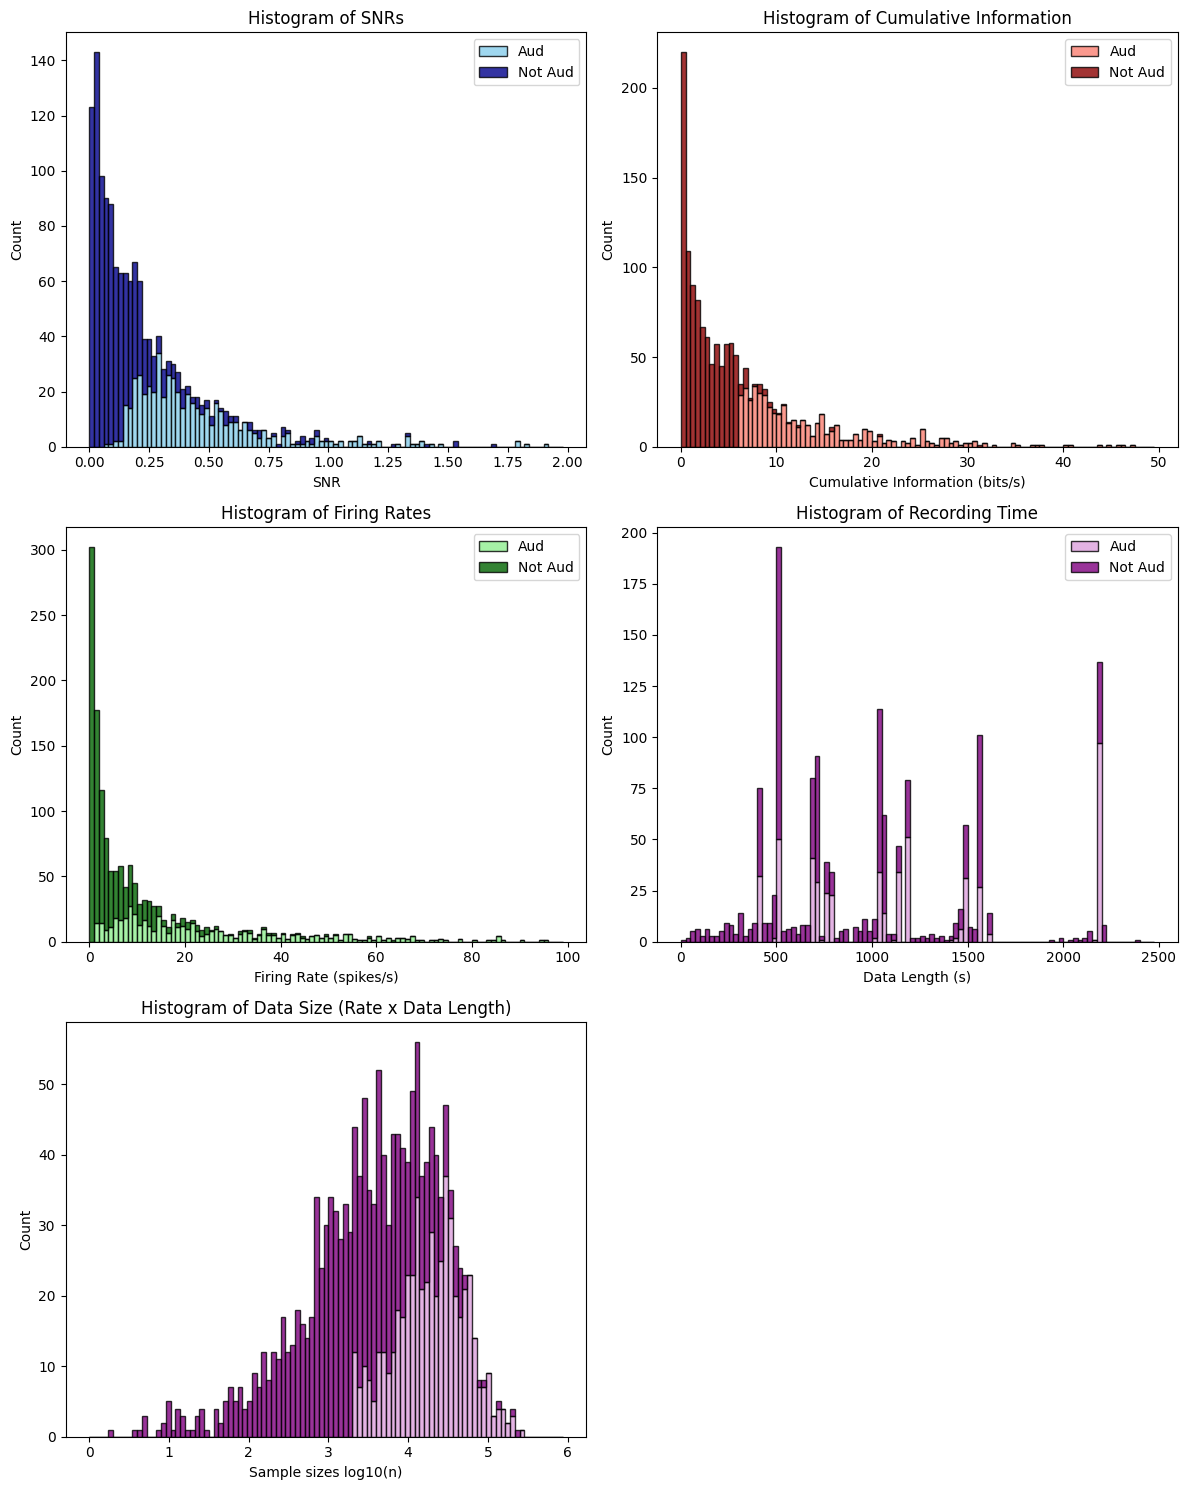

In [12]:
# Plot histograms
# We need to figure out thresholds for auditory units.  I propose this:

information_threshold = 6.0 # in bits/s
snr_threshold = 0.0 # unitless
rate_threshold = 1.0 # average evoked rate in spikes/s
data_size_threshold = 2000 # Requiring at leat 2000 spikes.

# Find units that meet all criteria (audtiory units) and perform count statistics to determine whether there is a difference in number of auditory units in Field L vs NCM.  We can use a Fisher's exact test for this.
idx = (snrs > snr_threshold) & (infos > information_threshold) & (rate > rate_threshold) & (rate*data_length/1000 > data_size_threshold)
print(f"Number of units with SNR > {snr_threshold} and Information > {information_threshold} and Rate > {rate_threshold} and Data Size > {data_size_threshold}: {np.sum(idx)}/{len(snrs)}")
nL_units = np.sum(brain_areas == 'L')
nNCM_units = np.sum(brain_areas == 'NCM')
idx_L = idx & (brain_areas == 'L')
print(f"Number of auditory units in Field L with these criteria: {np.sum(idx_L)}/{nL_units} ({np.sum(idx_L)/nL_units*100:.1f}%)")
idx_NCM = idx & (brain_areas == 'NCM')
print(f"Number of auditory units in NCM with these criteria: {np.sum(idx_NCM)}/{nNCM_units} ({np.sum(idx_NCM)/nNCM_units*100:.1f}%)")
nL_Aud_units = np.sum(idx_L)
nNCM_Aud_units = np.sum(idx_NCM)
table = np.array([[nL_Aud_units, nL_units - nL_Aud_units], [nNCM_Aud_units, nNCM_units - nNCM_Aud_units]])
oddsratio, pvalue = stats.fisher_exact(table, alternative='two-sided')
print(f"Odds ratio: {oddsratio}")
print(f"P-value: {pvalue}")

# Cell types per area
L_bs_idx = idx_L & (unit_types == 'bs')
L_ns_idx = idx_L & (unit_types == 'ns')
NCM_bs_idx = idx_NCM & (unit_types == 'bs')
NCM_ns_idx = idx_NCM & (unit_types == 'ns')
nL_bs = np.sum(L_bs_idx)
nL_ns = np.sum(L_ns_idx)
nNCM_bs = np.sum(NCM_bs_idx)
nNCM_ns = np.sum(NCM_ns_idx)
print(f"Number of auditory units in Field L that are bs: {nL_bs}/{nL_Aud_units} ({nL_bs/nL_Aud_units*100:.1f}%)")
print(f"Number of auditory units in Field L that are ns: {nL_ns}/{nL_Aud_units} ({nL_ns/nL_Aud_units*100:.1f}%)")
print(f"Number of auditory units in NCM that are bs: {nNCM_bs}/{nNCM_Aud_units} ({nNCM_bs/nNCM_Aud_units*100:.1f}%)")
print(f"Number of auditory units in NCM that are ns: {nNCM_ns}/{nNCM_Aud_units} ({nNCM_ns/nNCM_Aud_units*100:.1f}%)")
table = np.array([[nL_bs, nL_ns], [nNCM_bs, nNCM_ns]])
oddsratio, pvalue = stats.fisher_exact(table, alternative='two-sided')
print(f"Odds ratio for cell type distribution: {oddsratio}")
print(f"P-value for cell type distribution: {pvalue}")


# Histograms of all parameters
plt.figure(figsize=(12, 15))

# Histogram of SNRs
plt.subplot(3, 2, 1)
bins = np.arange(0, 2.0, 2.0/100)
list_of_data = [snrs[idx], snrs[~idx]]
labels = ['Aud', 'Not Aud']
colors = ['skyblue', 'darkblue']
plt.hist(list_of_data, bins=bins, stacked=True, label=labels, color=colors, edgecolor='black', alpha=0.8)
plt.title('Histogram of SNRs')
plt.legend()
plt.xlabel('SNR')
plt.ylabel('Count')


# Histogram of cumulative information
plt.subplot(3, 2, 2)
bins = np.arange(0, 50, 50/100)
list_of_data = [infos[idx], infos[~idx]]
labels = ['Aud', 'Not Aud']
colors = ['salmon', 'darkred']
plt.hist(list_of_data, bins=bins, stacked=True, label=labels, color=colors, edgecolor='black', alpha=0.8)
plt.title('Histogram of Cumulative Information')
plt.legend()
plt.xlabel('Cumulative Information (bits/s)')
plt.ylabel('Count')

# Histogram of firing rates
plt.subplot(3, 2, 3)
bins = np.arange(0, 100.0, 100.0/100)
list_of_data = [rate[idx], rate[~idx]]
labels = ['Aud', 'Not Aud']
colors = ['lightgreen', 'darkgreen']
plt.hist(list_of_data, bins=bins, stacked=True, label=labels, color=colors, edgecolor='black', alpha=0.8)
plt.title('Histogram of Firing Rates')
plt.legend()
plt.xlabel('Firing Rate (spikes/s)')
plt.ylabel('Count')

# Histogram of recording time
plt.subplot(3, 2, 4)
bins = np.arange(0, 2500.0, 2500.0/100)
list_of_data = [data_length[idx]/1000, data_length[~idx]/1000]
labels = ['Aud', 'Not Aud']
colors = ['plum', 'purple']
plt.hist(list_of_data, bins=bins, stacked=True, label=labels, color=colors, edgecolor='black', alpha=0.8 )
plt.title('Histogram of Recording Time')
plt.legend()
plt.xlabel('Data Length (s)')
plt.ylabel('Count')

# Histogram of data size (rate x data length)
plt.subplot(3, 2, 5)
bins = np.arange(0, 6.0, 6.0/100)
list_of_data = [np.log10(rate[idx]*data_length[idx]/1000), np.log10(rate[~idx]*data_length[~idx]/1000)]
labels = ['Aud', 'Not Aud']
colors = ['plum', 'purple']
plt.hist(list_of_data, bins=bins, stacked=True, label=labels, color=colors, edgecolor='black', alpha=0.8 )
plt.title('Histogram of Data Size (Rate x Data Length)')
plt.legend
plt.xlabel('Sample sizes log10(n)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()




We end up with 520/1504 auditory units. 

## Differences in information and rates between NS and BS neuros

These three plots could be in supplemental material and just mentionned in the text.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


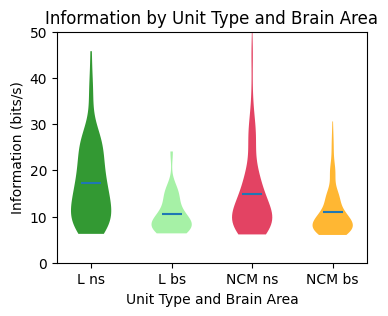

                                  sum_sq     df          F        PR(>F)
C(Unit_Type)                 2426.238092    1.0  41.491661  2.706924e-10
C(Brain_Area)                 205.922110    1.0   3.521522  6.113874e-02
C(Unit_Type):C(Brain_Area)    131.900415    1.0   2.255660  1.337360e-01
Residual                    30290.215212  518.0        NaN           NaN


In [13]:
# Make a violin plot of cumulative information by unit type and brain area.
unit_brain_labels = [('L', 'ns'), ('L', 'bs'), ('NCM', 'ns'), ('NCM', 'bs')]

data_to_plot = [infos[(unit_types == ut[1]) & (brain_areas == ut[0]) & idx] for ut in unit_brain_labels] 
plt.figure(figsize=(4, 3))
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('lightgreen')
parts['bodies'][2].set_facecolor('crimson')
parts['bodies'][3].set_facecolor('orange')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
parts['bodies'][3].set_alpha(0.8)
plt.xticks([1, 2, 3, 4], [f"{ut[0]} {ut[1]}" for ut in unit_brain_labels])
plt.title('Information by Unit Type and Brain Area')
plt.xlabel('Unit Type and Brain Area')
plt.ylabel('Information (bits/s)')
plt.ylim(0, 50)
plt.savefig('/Users/frederictheunissen/Desktop/bits_per_second.eps', dpi=300)
plt.show()

pdInfo = pd.DataFrame({
    'Information': np.concatenate(data_to_plot),
    'Unit_Type': np.concatenate([[ut[1]] * len(d) for ut, d in zip(unit_brain_labels, data_to_plot)]),
    'Brain_Area': np.concatenate([[ut[0]] * len(d) for ut, d in zip(unit_brain_labels, data_to_plot)])
})

# Anova with interaction
model = smf.ols('Information ~ C(Unit_Type) * C(Brain_Area)', data=pdInfo).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

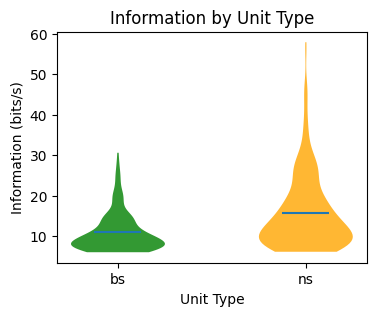

Mean Information for bs: 10.90 +- 0.337, ns: 15.64 +- 0.508
T-test between unit types bs and ns: t-statistic = -7.748, p-value = 5.19e-14


In [14]:
# Repeat merging data.
unit_type_labels = ['bs', 'ns']
data_to_plot = [infos[(unit_types == ut) & idx] for ut in unit_type_labels] 
plt.figure(figsize=(4, 3))
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('orange')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
plt.xticks([1, 2], unit_type_labels)
plt.title('Information by Unit Type')
plt.xlabel('Unit Type')
plt.ylabel('Information (bits/s)')
plt.show()

t_stat, p_val = stats.ttest_ind(data_to_plot[0], data_to_plot[1], equal_var=False)
print(f"Mean Information for bs: {np.mean(data_to_plot[0]):.2f} +- {np.std(data_to_plot[0])/np.sqrt(len(data_to_plot[0])):.3f}, ns: {np.mean(data_to_plot[1]):.2f} +- {np.std(data_to_plot[1])/np.sqrt(len(data_to_plot[1])):.3f}")
print(f"T-test between unit types bs and ns: t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


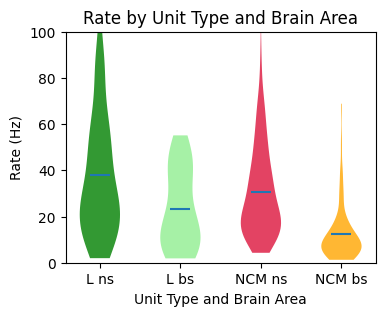

                                   sum_sq     df           F        PR(>F)
C(Unit_Type)                 38125.944774    1.0  107.242116  5.732973e-23
C(Brain_Area)                 5851.039251    1.0   16.458027  5.740503e-05
C(Unit_Type):C(Brain_Area)     277.436737    1.0    0.780385  3.774333e-01
Residual                    184155.629342  518.0         NaN           NaN


In [15]:
# Make a violin plot for rate by unit type and brain area.
unit_brain_labels = [('L', 'ns'), ('L', 'bs'), ('NCM', 'ns'), ('NCM', 'bs')]
data_to_plot = [rate[(unit_types == ut[1]) & (brain_areas == ut[0]) & idx] for ut in unit_brain_labels] 

plt.figure(figsize=(4, 3))
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('lightgreen')
parts['bodies'][2].set_facecolor('crimson')
parts['bodies'][3].set_facecolor('orange')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
parts['bodies'][3].set_alpha(0.8)
plt.xticks([1, 2, 3, 4], [f"{ut[0]} {ut[1]}" for ut in unit_brain_labels])
plt.title('Rate by Unit Type and Brain Area')
plt.xlabel('Unit Type and Brain Area')
plt.ylabel('Rate (Hz)')
plt.ylim(0, 100)
plt.savefig('/Users/frederictheunissen/Desktop/rate_by_unit_type_and_brain_area.eps', dpi=300)
plt.show()

# Anova with interaction for rate
pdRate = pd.DataFrame({
    'Rate': np.concatenate(data_to_plot),
    'Unit_Type': np.concatenate([[ut[1]] * len(d) for ut, d in zip(unit_brain_labels, data_to_plot)]),
    'Brain_Area': np.concatenate([[ut[0]] * len(d) for ut, d in zip(unit_brain_labels, data_to_plot)])
})
model = smf.ols('Rate ~ C(Unit_Type) * C(Brain_Area)', data=pdRate).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

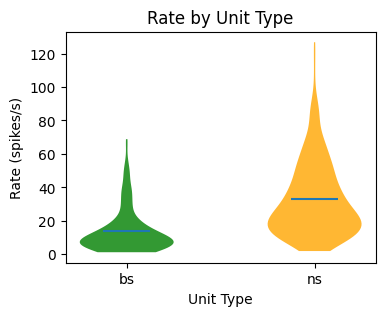

Mean Rate for bs: 13.78 +- 0.907, ns: 32.88 +- 1.247
T-test between unit types bs and ns: t-statistic = -12.360, p-value = 6.5e-31


In [16]:
# Make a violin plot of rate by unit type
unit_type_labels = ['bs', 'ns']
data_to_plot = [rate[(unit_types == ut) & idx] for ut in unit_type_labels] 
plt.figure(figsize=(4, 3))
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('orange')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
plt.xticks([1, 2], unit_type_labels)
plt.title('Rate by Unit Type')
plt.xlabel('Unit Type')
plt.ylabel('Rate (spikes/s)')
plt.show()

t_stat, p_val = stats.ttest_ind(data_to_plot[0], data_to_plot[1], equal_var=False)
print(f"Mean Rate for bs: {np.mean(data_to_plot[0]):.2f} +- {np.std(data_to_plot[0])/np.sqrt(len(data_to_plot[0])):.3f}, ns: {np.mean(data_to_plot[1]):.2f} +- {np.std(data_to_plot[1])/np.sqrt(len(data_to_plot[1])):.3f}")
print(f"T-test between unit types bs and ns: t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


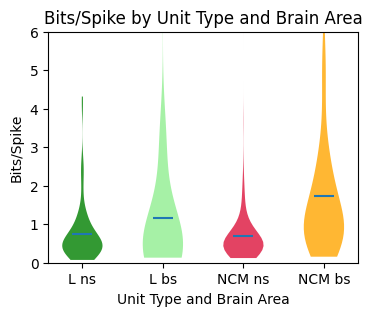

                                sum_sq     df          F        PR(>F)
C(Unit_Type)                106.256281    1.0  64.323917  7.083479e-15
C(Brain_Area)                 1.211299    1.0   0.733279  3.922184e-01
C(Unit_Type):C(Brain_Area)    6.908019    1.0   4.181879  4.136320e-02
Residual                    855.681001  518.0        NaN           NaN


In [17]:
# Make a violin plot of bits/spike by unit type and brain area.
unit_brain_labels = [('L', 'ns'), ('L', 'bs'), ('NCM', 'ns'), ('NCM', 'bs')]
data_to_plot = [infos[(unit_types == ut[1]) & (brain_areas == ut[0]) & idx] / rate[(unit_types == ut[1]) & (brain_areas == ut[0]) & idx] for ut in unit_brain_labels]
plt.figure(figsize=(4, 3))
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('lightgreen')
parts['bodies'][2].set_facecolor('crimson')
parts['bodies'][3].set_facecolor('orange')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
parts['bodies'][3].set_alpha(0.8)
plt.xticks([1, 2, 3, 4], [f"{ut[0]} {ut[1]}" for ut in unit_brain_labels])
plt.title('Bits/Spike by Unit Type and Brain Area')
plt.xlabel('Unit Type and Brain Area')
plt.ylabel('Bits/Spike')
plt.ylim(0, 6)
plt.savefig('/Users/frederictheunissen/Desktop/bits_per_spike.eps', dpi=300)
plt.show()

# Anova with interaction for bits/spike
pdBitsPerSpike = pd.DataFrame({
    'BitsPerSpike': np.concatenate(data_to_plot),
    'Unit_Type': np.concatenate([[ut[1]] * len(d) for ut, d in zip(unit_brain_labels, data_to_plot)]),
    'Brain_Area': np.concatenate([[ut[0]] * len(d) for ut, d in zip(unit_brain_labels, data_to_plot)])
})
model = smf.ols('BitsPerSpike ~ C(Unit_Type) * C(Brain_Area)', data=pdBitsPerSpike).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

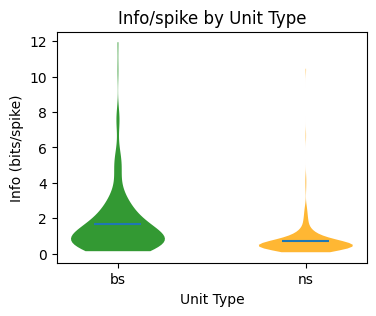

Mean Info/spike for bs: 1.66 +- 0.122, ns: 0.70 +- 0.048
T-test between unit types bs and ns: t-statistic = 7.275, p-value = 3.83e-12


In [18]:
# Make a violin plot of bits/spike by unit type
unit_type_labels = ['bs', 'ns']
data_to_plot = [infos[(unit_types == ut) & idx]/rate[(unit_types == ut) & idx] for ut in unit_type_labels] 
plt.figure(figsize=(4, 3))
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('orange')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
plt.xticks([1, 2], unit_type_labels)
plt.title('Info/spike by Unit Type')
plt.xlabel('Unit Type')
plt.ylabel('Info (bits/spike)')
plt.show()

t_stat, p_val = stats.ttest_ind(data_to_plot[0], data_to_plot[1], equal_var=False)
print(f"Mean Info/spike for bs: {np.mean(data_to_plot[0]):.2f} +- {np.std(data_to_plot[0])/np.sqrt(len(data_to_plot[0])):.3f}, ns: {np.mean(data_to_plot[1]):.2f} +- {np.std(data_to_plot[1])/np.sqrt(len(data_to_plot[1])):.3f}")
print(f"T-test between unit types bs and ns: t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")

### Relationship between Information, SNR and firing rate

This is also good supplmental material

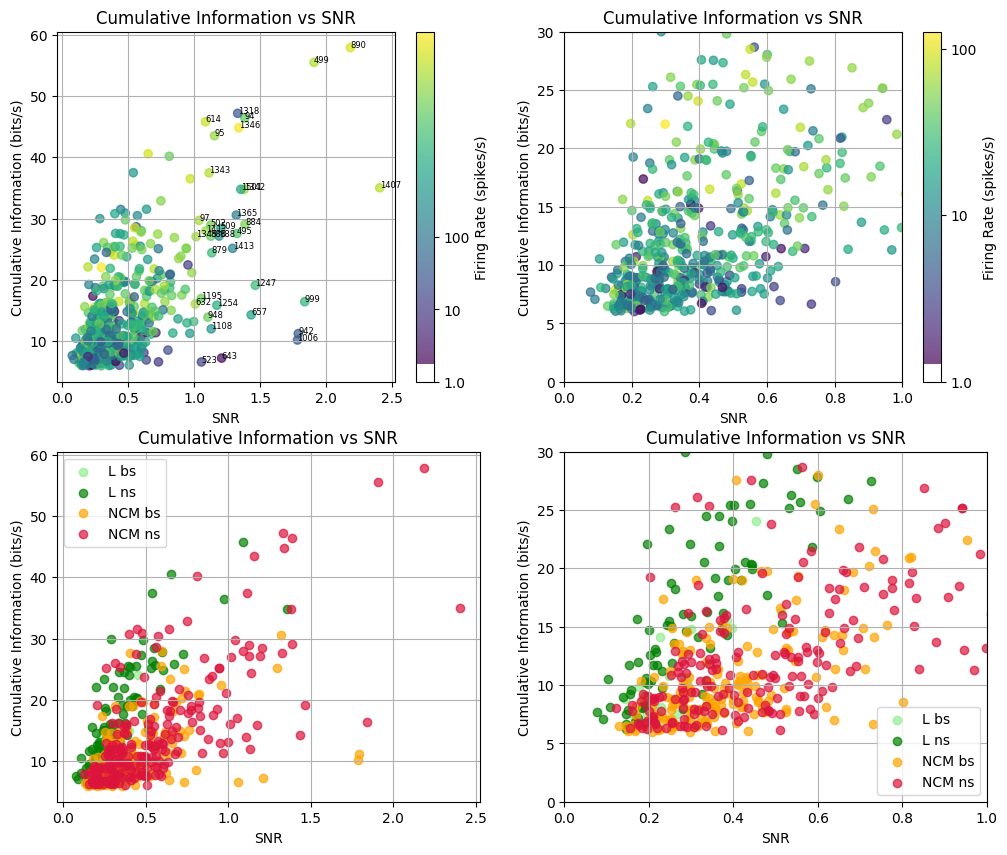

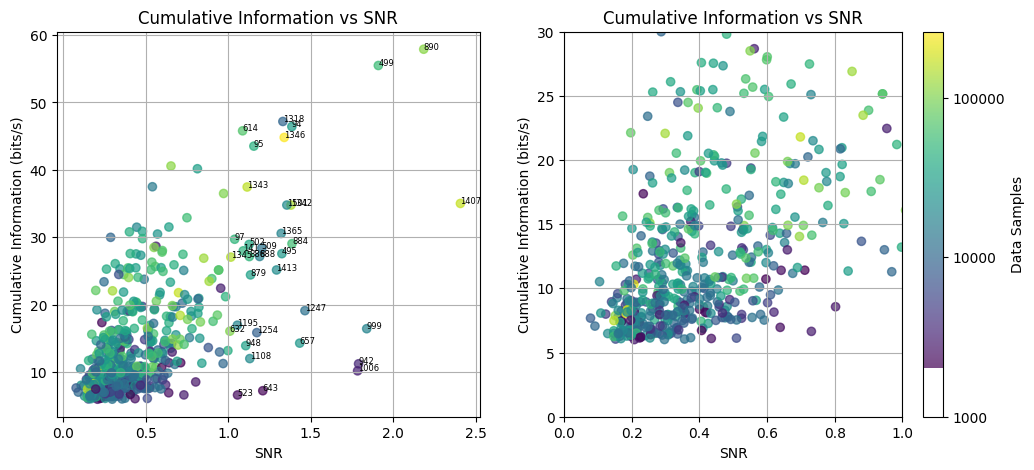

In [19]:
# Scatter plot of cumulative information vs SNR colored by rate

plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
plt.scatter(snrs[idx], infos[idx], c = np.log(rate[idx]), cmap ='viridis', alpha=0.7)
plt.title('Cumulative Information vs SNR')
plt.xlabel('SNR')
plt.ylabel('Cumulative Information (bits/s)')
cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.grid(True)
# Add text labels for snr> 1
for i, snr in enumerate(snrs):
    if idx[i] and snr > 1.0:
        plt.text(snrs[i], infos[i], f"{i}", fontsize=6)

# Zoome in on low SNR region
plt.subplot(2,2,2)
plt.scatter(snrs[idx], infos[idx], c = np.log10(rate[idx]), cmap ='viridis', alpha=0.7)
plt.title('Cumulative Information vs SNR')
plt.xlim((0.0, 1.0))
plt.xlabel('SNR')
plt.ylim((0.0, 30.0))
plt.ylabel('Cumulative Information (bits/s)')
cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.grid(True)

# Repeat using unit_types for color

plt.subplot(2,2,3)
plt.scatter(snrs[L_bs_idx], infos[L_bs_idx], c = 'lightgreen', label='L bs', alpha=0.7)
plt.scatter(snrs[L_ns_idx], infos[L_ns_idx], c = 'green', label='L ns', alpha=0.7)
plt.scatter(snrs[NCM_bs_idx], infos[NCM_bs_idx], c = 'orange', label='NCM bs', alpha=0.7)
plt.scatter(snrs[NCM_ns_idx], infos[NCM_ns_idx], c = 'crimson', label='NCM ns', alpha=0.7)
plt.title('Cumulative Information vs SNR')
plt.xlabel('SNR')
plt.ylabel('Cumulative Information (bits/s)')
plt.legend()
plt.grid(True)

# Zoom in on low SNR region
plt.subplot(2,2,4)
plt.scatter(snrs[L_bs_idx], infos[L_bs_idx], c = 'lightgreen', label='L bs', alpha=0.7)
plt.scatter(snrs[L_ns_idx], infos[L_ns_idx], c = 'green', label='L ns', alpha=0.7)
plt.scatter(snrs[NCM_bs_idx], infos[NCM_bs_idx], c = 'orange', label='NCM bs', alpha=0.7)
plt.scatter(snrs[NCM_ns_idx], infos[NCM_ns_idx], c = 'crimson', label='NCM ns', alpha=0.7)
plt.title('Cumulative Information vs SNR')
plt.xlim((0.0, 1.0))
plt.xlabel('SNR')
plt.ylim((0.0, 30.0))
plt.ylabel('Cumulative Information (bits/s)')
plt.legend()
plt.grid(True)

plt.show()

# Scatter plot of cumulative information vs SNR colored by square root total data 

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.scatter(snrs[idx], infos[idx], c = np.log10(rate[idx]*data_length[idx]/1000), cmap ='viridis', alpha=0.7)
plt.title('Cumulative Information vs SNR')
plt.xlabel('SNR')
plt.ylabel('Cumulative Information (bits/s)')
plt.grid(True)
# Add text labels for snr> 1
for i, snr in enumerate(snrs):
    if idx[i] and snr > 1.0:
        plt.text(snrs[i], infos[i], f"{i}", fontsize=6)
plt.subplot(1,2,2)
plt.scatter(snrs[idx], infos[idx], c = np.log10(rate[idx]*data_length[idx]/1000), cmap ='viridis', alpha=0.7)
plt.title('Cumulative Information vs SNR')
plt.xlim((0.0, 1.0))
plt.xlabel('SNR')
plt.ylim((0.0, 30.0))
plt.ylabel('Cumulative Information (bits/s)')
cbar = plt.colorbar(label='Data Samples')
tickvalues = cbar.get_ticks()
cbar.set_ticks([3.0, 4.0, 5.0])
cbar.set_ticklabels([1000, 10000, 100000])
plt.grid(True)

plt.show()

In [20]:
# These are high SNR units but low information. THey all have low firing rates. We could potentially exclude...

units_to_label = [1435, 645]

for i_unit in units_to_label:
        print(f"Unit {i_unit} found in Bird {birds[i_unit]} - Unit {units[i_unit]} - File: {nwbFiles[i_unit]}: SNR={snrs[i_unit]:.2f}, Info={infos[i_unit]:.2f}, Rate={rate[i_unit]:.2f}, Data Length={data_length[i_unit]/1000:.0f} s")

Unit 1435 found in Bird HpiRed7670F - Unit 24 - File: HpiRed7670F_site03_241018_090306_pb_op_ks4_lat_250215: SNR=0.05, Info=1.47, Rate=5.58, Data Length=1187 s
Unit 645 found in Bird BlaBla3736M - Unit 31 - File: BlaBla3736M_d4_240816_144048_ks4_lat_250416: SNR=0.40, Info=3.67, Rate=1.10, Data Length=1453 s


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/902490332.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)


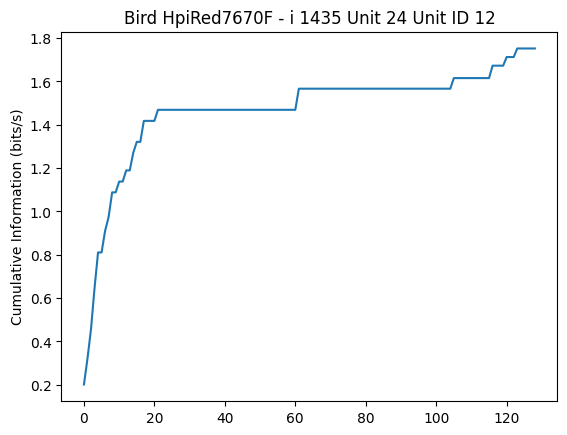

Unit 1435 found in Bird HpiRed7670F - Unit 24: SNR=0.045976904934508143, Info=1.4691096648645032, Rate=5.579396740562944, Data size=6621.293287895668 spikes


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/902490332.py:12: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)


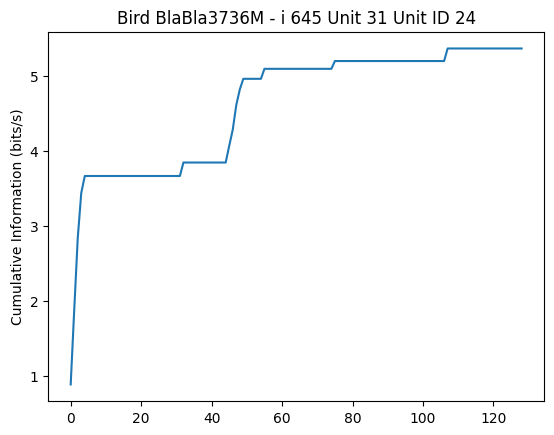

Unit 645 found in Bird BlaBla3736M - Unit 31: SNR=0.39639706679389086, Info=3.6654208737394147, Rate=1.0971626624507653, Data size=1594.6096306299676 spikes


In [21]:
# Plot the information for these neurons

for i_unit in units_to_label:
        bird  = birds[i_unit]
        unit = units[i_unit]
        unit_id = unit_ids[i_unit]

        # Read that data file and get the row. 
       
        file_path = os.path.join(data_dir, bird + '_' + nwbFiles[i_unit] + '_strf_results.pkl')
        with open(file_path, 'rb') as infile:
                dataFrame  = pkl.load(infile)
        for i, row in dataFrame.iterrows():
                if row['unit'] == unit and row['unit_id'] == unit_id:
                        plt.figure()
                        plt.plot(row['cumInfo'])
                        plt.title(f'Bird {bird} - i {i_unit} Unit {unit} Unit ID {unit_id}') 
                        plt.ylabel('Cumulative Information (bits/s)')
                        plt.show()
                        print(f"Unit {i_unit} found in Bird {birds[i_unit]} - Unit {units[i_unit]}: SNR={snrs[i_unit]}, Info={infos[i_unit]}, Rate={rate[i_unit]}, Data size={rate[i_unit]*data_length[i_unit]/1000} spikes")
                        break



/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/3087248531.py:32: RuntimeWarning: divide by zero encountered in divide
  model_idx = r2segIds/r2Ceils > r2_threshold


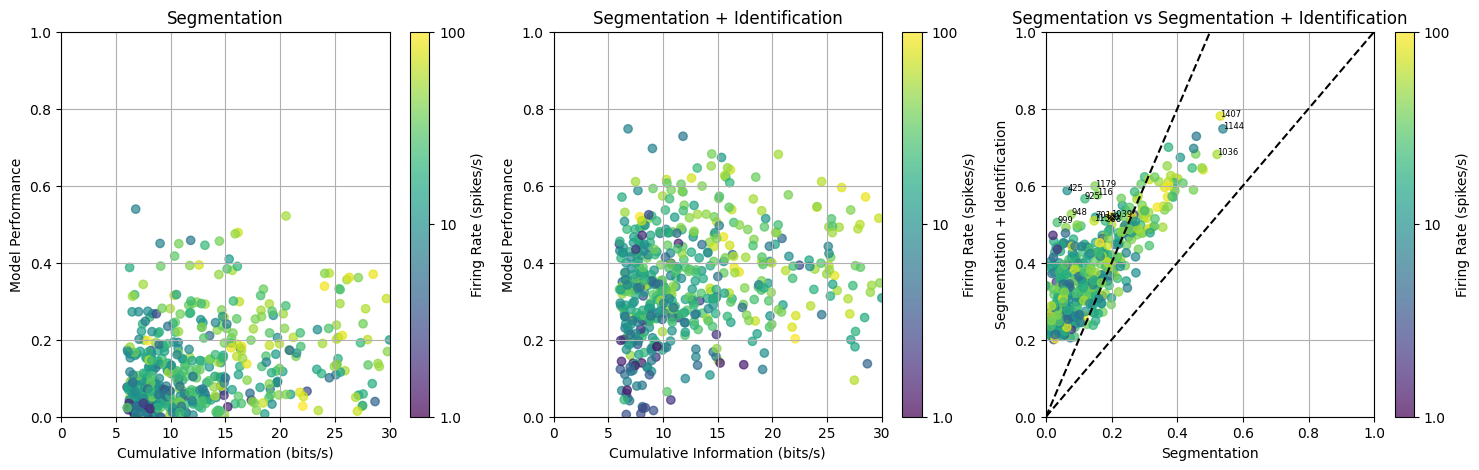

-----------------------Count Statistics for Encoding Model-----------------------
Number of units with encoding models above 20.0% (R2 (corrected) > 0.2): 449/522
	 Number of L bs units : 27/27 (100.0%)
	 Number of L ns units : 89/92 (96.7%)
		Number of L units : 116/119 (97.5%)
	 Number of NCM bs units : 125/179 (69.8%)
	 Number of NCM ns units : 208/224 (92.9%)
		Number of NCM units : 333/403 (82.6%)
Logistic regression results for whether a unit is modeled by the encoding model based on area, cell type, and their interaction:
                  Generalized Linear Model Regression Results                  
Dep. Variable:     ['modeled', 'notM']   No. Observations:                    4
Model:                             GLM   Df Residuals:                        0
Model Family:                 Binomial   Df Model:                            3
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:         

/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or p

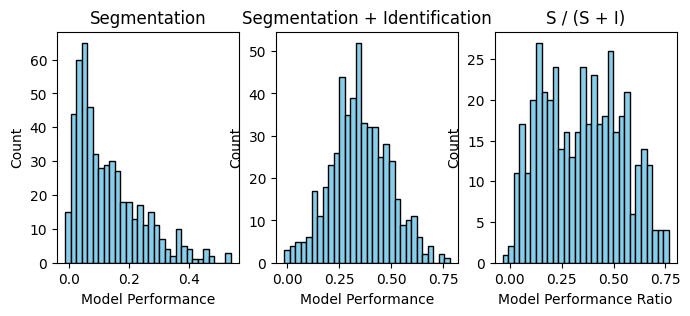

-----------------------Statistics Comparing Performance by Unit Type Ignoting Brain Regions (t-tests) -----------------------
-----------------------Statistics for S Model Performance by Unit Type-----------------------
S Model Performance for bs: 0.12 +- 0.007, ns: 0.16 +- 0.007
T-test between unit types bs and ns: t-statistic = -3.999, p-value = 7.56e-05
------------------------Statistics for S + I Model Performance by Unit Type-----------------------
S +I Model Performance for bs: 0.36 +- 0.008, ns: 0.40 +- 0.007
T-test between unit types bs and ns: t-statistic = -3.173, p-value = 0.00163
-----------------------Statistics for S/S+I by Unit Type-----------------------
Performance Ratio for bs: 0.32 +- 0.014, ns: 0.37 +- 0.012
T-test between unit types bs and ns: t-statistic = -2.837, p-value = 0.00481


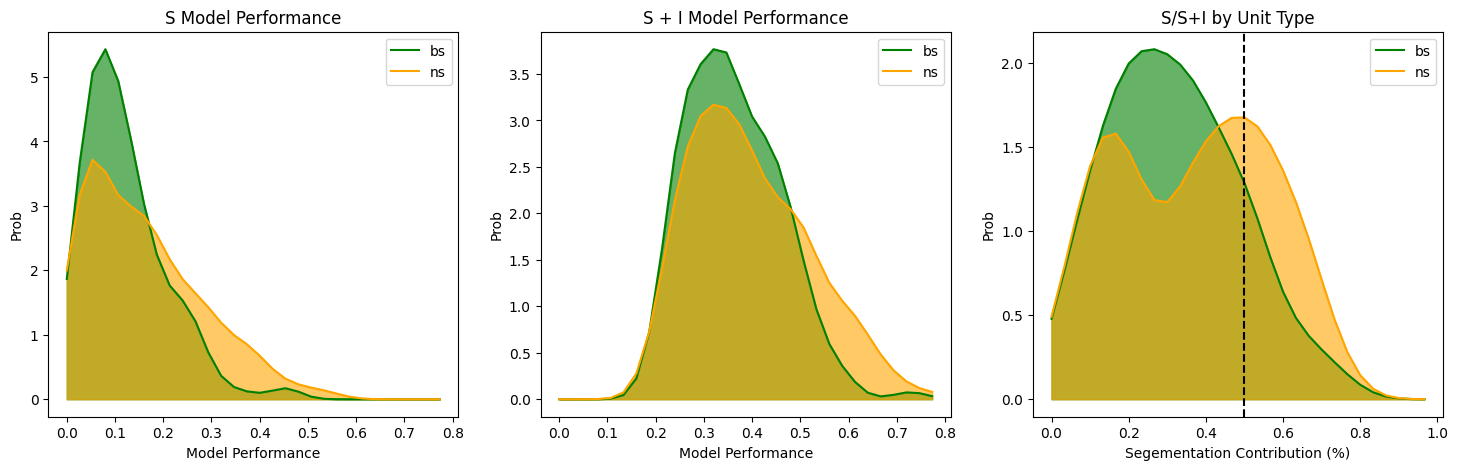

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


-----------------------Statistics Comparing Performance by Unit Type and Brain Area (ANOVA with Interaction) -----------------------
----------------------- ANOVA for R2Seg -----------------------
                              sum_sq     df           F        PR(>F)
C(Unit_Type)                0.061560    1.0    6.559996  1.075831e-02
C(Brain_Area)               1.118835    1.0  119.226577  9.401396e-25
C(Unit_Type):C(Brain_Area)  0.002704    1.0    0.288156  5.916732e-01
Residual                    4.175927  445.0         NaN           NaN
----------------------- ANOVA for R2SegID -----------------------
                              sum_sq     df          F        PR(>F)
C(Unit_Type)                0.056561    1.0   4.772959  2.943111e-02
C(Brain_Area)               0.492547    1.0  41.564321  2.973554e-10
C(Unit_Type):C(Brain_Area)  0.000880    1.0   0.074290  7.853171e-01
Residual                    5.273358  445.0        NaN           NaN
----------------------- ANOVA for R2SegFra

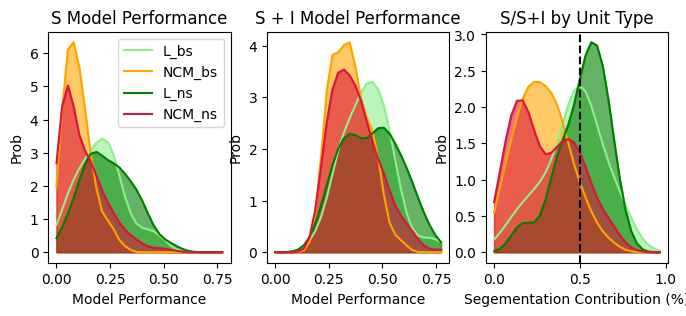

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


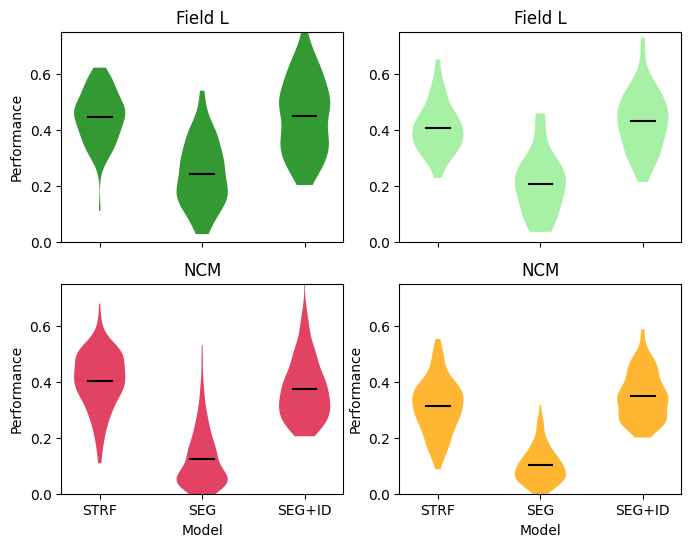

-----------------------Pairwise t-tests Comparing Model Performance by Unit Type and Brain Area (Bonferroni Correction)-----------------------
Bonferroni corrected alpha for 12 comparisons: 0.0042
L_bs: STRF vs SEG: t-statistic = 9.752, p-value = 3.567e-10, significant after correction: True
L_bs: STRF vs SEG+ID: t-statistic = -1.117, p-value = 0.2742, significant after correction: False
L_bs: SEG vs SEG+ID: t-statistic = -16.265, p-value = 3.818e-15, significant after correction: True
L_ns: STRF vs SEG: t-statistic = 20.686, p-value = 1.485e-35, significant after correction: True
L_ns: STRF vs SEG+ID: t-statistic = -0.140, p-value = 0.8886, significant after correction: False
L_ns: SEG vs SEG+ID: t-statistic = -35.470, p-value = 6.606e-54, significant after correction: True
NCM_bs: STRF vs SEG: t-statistic = 22.631, p-value = 7.449e-46, significant after correction: True
NCM_bs: STRF vs SEG+ID: t-statistic = -3.655, p-value = 0.0003777, significant after correction: True
NCM_bs: SEG v

In [22]:
# Make scatter plots of model performance vs information

plt.figure(figsize=(18, 5))
plt.subplot(1,3,1)
plt.scatter(infos[idx], r2Segs[idx]/r2Ceils[idx], c = np.log10(rate[idx]), cmap ='viridis', alpha=0.7, clim=(np.log10(rate_threshold), 2.0))
plt.title('Segmentation')
plt.xlabel('Cumulative Information (bits/s)')
plt.ylabel('Model Performance')
cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.xlim((0.0, 30.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(1,3,2)
plt.scatter(infos[idx], r2segIds[idx]/r2Ceils[idx], c = np.log10(rate[idx]), cmap ='viridis', alpha=0.7, clim=(np.log10(rate_threshold), 2.0))
plt.title('Segmentation + Identification')
plt.xlabel('Cumulative Information (bits/s)')
plt.ylabel('Model Performance')
cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.xlim((0.0, 30.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

# Units predicted by encoding model
r2_threshold = 0.2
model_idx = r2segIds/r2Ceils > r2_threshold
idx_model = idx & model_idx
idx_model_L_bs = L_bs_idx & model_idx
idx_model_L_ns = L_ns_idx & model_idx
idx_model_NCM_bs = NCM_bs_idx & model_idx
idx_model_NCM_ns = NCM_ns_idx & model_idx

plt.subplot(1,3,3)
plt.scatter(r2Segs[idx_model]/r2Ceils[idx_model], r2segIds[idx_model]/r2Ceils[idx_model], c = np.log10(rate[idx_model]), cmap ='viridis', alpha=0.7, clim=(np.log10(rate_threshold), 2.0))
plt.plot([0, 1], [0, 1], 'k--')
plt.plot([0, 1], [0, 2], 'k--')
plt.title('Segmentation vs Segmentation + Identification')
plt.xlabel('Segmentation')
plt.ylabel('Segmentation + Identification')
# Add text labels for snr> 1
for i in range(len(r2Segs)):
    if idx_model[i] and ((r2Segs[i]/r2Ceils[i]) < 0.2) and ((r2segIds[i]/r2Ceils[i]) > 0.5):
        plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6)
    if idx_model[i] and ((r2Segs[i]/r2Ceils[i]) > 0.5) and ((r2segIds[i]/r2Ceils[i]) > 0.5) and ((r2Segs[i]/(r2segIds[i])) > 0.6):
        plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6)  

cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.show()

# COunt statistics
print("-----------------------Count Statistics for Encoding Model-----------------------")

print(f"Number of units with encoding models above {r2_threshold*100}% (R2 (corrected) > {r2_threshold}): {np.sum(idx_model)}/{np.sum(idx)}")
print(f"\t Number of L bs units : {np.sum(idx_model_L_bs)}/{np.sum(L_bs_idx)} ({np.sum(idx_model_L_bs)/np.sum(L_bs_idx)*100:.1f}%)")
print(f"\t Number of L ns units : {np.sum(idx_model_L_ns)}/{np.sum(L_ns_idx)} ({np.sum(idx_model_L_ns)/np.sum(L_ns_idx)*100:.1f}%)")
print(f"\t\tNumber of L units : {np.sum(idx_model_L_bs) + np.sum(idx_model_L_ns)}/{np.sum(L_bs_idx) + np.sum(L_ns_idx)} ({(np.sum(idx_model_L_bs) + np.sum(idx_model_L_ns))/(np.sum(L_bs_idx) + np.sum(L_ns_idx))*100:.1f}%)")
print(f"\t Number of NCM bs units : {np.sum(idx_model_NCM_bs)}/{np.sum(NCM_bs_idx)} ({np.sum(idx_model_NCM_bs)/np.sum(NCM_bs_idx)*100:.1f}%)")
print(f"\t Number of NCM ns units : {np.sum(idx_model_NCM_ns)}/{np.sum(NCM_ns_idx)} ({np.sum(idx_model_NCM_ns)/np.sum(NCM_ns_idx)*100:.1f}%)")
print(f"\t\tNumber of NCM units : {np.sum(idx_model_NCM_bs) + np.sum(idx_model_NCM_ns)}/{np.sum(NCM_bs_idx) + np.sum(NCM_ns_idx)} ({(np.sum(idx_model_NCM_bs) + np.sum(idx_model_NCM_ns))/(np.sum(NCM_bs_idx) + np.sum(NCM_ns_idx))*100:.1f}%)")


tbTest = pd.DataFrame({
  'area'    : ['L', 'L', 'NCM', 'NCM'],
  'cell_type' : ['bs', 'ns', 'bs', 'ns'],
  'modeled' : [np.sum(idx_model_L_bs), np.sum(idx_model_L_ns), np.sum(idx_model_NCM_bs), np.sum(idx_model_NCM_ns)],
  'notM' : [np.sum(L_bs_idx) - np.sum(idx_model_L_bs), np.sum(L_ns_idx) - np.sum(idx_model_L_ns), np.sum(NCM_bs_idx) - np.sum(idx_model_NCM_bs), np.sum(NCM_ns_idx) - np.sum(idx_model_NCM_ns)]

})
lrTest = smf.glm('modeled + notM ~ area + cell_type + area:cell_type', tbTest, family=sm.families.Binomial()).fit()
print(f"Logistic regression results for whether a unit is modeled by the encoding model based on area, cell type, and their interaction:")
print(lrTest.summary())



# Histograms of model performance

plt.figure(figsize=(8, 3))
plt.subplot(1,3,1)
plt.hist(r2Segs[idx]/r2Ceils[idx], bins=30, color='skyblue', edgecolor='black')
plt.title('Segmentation')
plt.xlabel('Model Performance')
plt.ylabel('Count')

plt.subplot(1,3,2)
plt.hist(r2segIds[idx]/r2Ceils[idx], bins=30, color='skyblue', edgecolor='black')
plt.title('Segmentation + Identification')
plt.xlabel('Model Performance')
plt.ylabel('Count')

plt.subplot(1,3,3)
plt.hist((r2Segs[idx_model])/r2segIds[idx_model], bins=30, color='skyblue', edgecolor='black')
plt.title('S / (S + I)')
plt.xlabel('Model Performance Ratio')
plt.ylabel('Count')
plt.savefig('/Users/frederictheunissen/Desktop/Seg_vs_SegID_histogram.eps', dpi=300)

plt.show()

# Histograms of model performance stacked by unit type
plt.figure(figsize=(18, 5))
ax = plt.subplot(1,3,1)
bins = np.arange(0, 0.8, 0.8/30)
idx_bs = idx_model & (unit_types == 'bs')
idx_ns = idx_model & (unit_types == 'ns')
list_of_data = [r2Segs[idx_bs]/r2Ceils[idx_bs], r2Segs[idx_ns]/r2Ceils[idx_ns]]
labels = ['bs', 'ns']
colors = ['green', 'orange']
kernel_bs = stats.gaussian_kde(list_of_data[0])
kernel_ns = stats.gaussian_kde(list_of_data[1])
ax.plot(bins, kernel_bs(bins), color=colors[0], label=labels[0], alpha= 1.0)
ax.fill_between(bins, kernel_bs(bins), color=colors[0], alpha=0.6)
ax.plot(bins, kernel_ns(bins), color=colors[1], label=labels[1], alpha= 1.0)
ax.fill_between(bins, kernel_ns(bins), color=colors[1], alpha=0.6)
plt.legend()
plt.title('S Model Performance')
plt.xlabel('Model Performance')
plt.ylabel('Prob')
print("-----------------------Statistics Comparing Performance by Unit Type Ignoting Brain Regions (t-tests) -----------------------")
print("-----------------------Statistics for S Model Performance by Unit Type-----------------------")
t_stat, p_val = stats.ttest_ind(list_of_data[0], list_of_data[1], equal_var=False)
print(f"S Model Performance for bs: {np.mean(list_of_data[0]):.2f} +- {np.std(list_of_data[0])/np.sqrt(len(list_of_data[0])):.3f}, ns: {np.mean(list_of_data[1]):.2f} +- {np.std(list_of_data[1])/np.sqrt(len(list_of_data[1])):.3f}")
print(f"T-test between unit types bs and ns: t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")


plt.subplot(1,3,2)
bins = np.arange(0, 0.8, 0.8/30)
list_of_data = [r2segIds[idx_bs]/r2Ceils[idx_bs], r2segIds[idx_ns]/r2Ceils[idx_ns]]
ax = plt.gca()
kernel_bs = stats.gaussian_kde(list_of_data[0])
kernel_ns = stats.gaussian_kde(list_of_data[1])
ax.plot(bins, kernel_bs(bins), color=colors[0], label=labels[0], alpha= 1.0)
ax.fill_between(bins, kernel_bs(bins), color=colors[0], alpha=0.6)
ax.plot(bins, kernel_ns(bins), color=colors[1], label=labels[1], alpha= 1.0)
ax.fill_between(bins, kernel_ns(bins), color=colors[1], alpha=0.6)
plt.legend()
plt.title('S + I Model Performance')
plt.xlabel('Model Performance')
plt.ylabel('Prob')


print("------------------------Statistics for S + I Model Performance by Unit Type-----------------------")
t_stat, p_val = stats.ttest_ind(list_of_data[0], list_of_data[1], equal_var=False)
print(f"S +I Model Performance for bs: {np.mean(list_of_data[0]):.2f} +- {np.std(list_of_data[0])/np.sqrt(len(list_of_data[0])):.3f}, ns: {np.mean(list_of_data[1]):.2f} +- {np.std(list_of_data[1])/np.sqrt(len(list_of_data[1])):.3f}")
print(f"T-test between unit types bs and ns: t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")


ax = plt.subplot(1,3,3)
bins = np.arange(0, 1, 1/30)
idx_model_bs = idx_model & (unit_types == 'bs')
idx_model_ns = idx_model & (unit_types == 'ns')
list_of_data = [(r2Segs[idx_model_bs])/r2segIds[idx_model_bs], (r2Segs[idx_model_ns])/r2segIds[idx_model_ns]]
kernel_bs = stats.gaussian_kde(list_of_data[0])
kernel_ns = stats.gaussian_kde(list_of_data[1])
ax.plot(bins, kernel_bs(bins), color=colors[0], label=labels[0], alpha= 1.0)
ax.fill_between(bins, kernel_bs(bins), color=colors[0], alpha=0.6)
ax.plot(bins, kernel_ns(bins), color=colors[1], label=labels[1], alpha= 1.0)
ax.fill_between(bins, kernel_ns(bins), color=colors[1], alpha=0.6)
ax.axvline(0.5, color="k", linestyle='--')
plt.legend()
plt.title('S/S+I by Unit Type')
plt.xlabel('Segementation Contribution (%)')
plt.ylabel('Prob')

print("-----------------------Statistics for S/S+I by Unit Type-----------------------")
t_stat, p_val = stats.ttest_ind(list_of_data[0], list_of_data[1], equal_var=False)
print(f"Performance Ratio for bs: {np.mean(list_of_data[0]):.2f} +- {np.std(list_of_data[0])/np.sqrt(len(list_of_data[0])):.3f}, ns: {np.mean(list_of_data[1]):.2f} +- {np.std(list_of_data[1])/np.sqrt(len(list_of_data[1])):.3f}")
print(f"T-test between unit types bs and ns: t-statistic = {t_stat:.3f}, p-value = {p_val:.3g}")

plt.show()

# Histograms of model performance stacked by unit type and area.
plt.figure(figsize=(8, 3))
ax = plt.subplot(1,3,1)
bins = np.arange(0, 0.8, 0.8/30)
list_of_data = [r2Segs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2Segs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2Segs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2Segs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns]]
unit_brain_labels = [('L', 'bs'), ('NCM', 'bs'), ('L', 'ns'), ('NCM', 'ns')]
labels = ['L_bs', 'NCM_bs', 'L_ns', 'NCM_ns']
colors = ['lightgreen', 'orange', 'green', 'crimson']
kernel_L_bs = stats.gaussian_kde(list_of_data[0])
kernel_NCM_bs = stats.gaussian_kde(list_of_data[1])
kernel_L_ns = stats.gaussian_kde(list_of_data[2])
kernel_NCM_ns = stats.gaussian_kde(list_of_data[3])
ax.plot(bins, kernel_L_bs(bins), color=colors[0], label=labels[0], alpha= 1.0)
ax.fill_between(bins, kernel_L_bs(bins), color=colors[0], alpha=0.6)
ax.plot(bins, kernel_NCM_bs(bins), color=colors[1], label=labels[1], alpha= 1.0)
ax.fill_between(bins, kernel_NCM_bs(bins), color=colors[1], alpha=0.6)
ax.plot(bins, kernel_L_ns(bins), color=colors[2], label=labels[2], alpha= 1.0)
ax.fill_between(bins, kernel_L_ns(bins), color=colors[2], alpha=0.6)
ax.plot(bins, kernel_NCM_ns(bins), color=colors[3], label=labels[3], alpha= 1.0)
ax.fill_between(bins, kernel_NCM_ns(bins), color=colors[3], alpha=0.6)
plt.legend()
plt.title('S Model Performance')
plt.xlabel('Model Performance')
plt.ylabel('Prob')

print("-----------------------Statistics Comparing Performance by Unit Type and Brain Area (ANOVA with Interaction) -----------------------")
# Anova with interaction for R2 Seg
pdR2Seg = pd.DataFrame({
    'R2Seg': np.concatenate(list_of_data),
    'Unit_Type': np.concatenate([[ut[1]] * len(d) for ut, d in zip(unit_brain_labels, list_of_data)]),
    'Brain_Area': np.concatenate([[ut[0]] * len(d) for ut, d in zip(unit_brain_labels, list_of_data)])
})
model = smf.ols('R2Seg ~ C(Unit_Type) * C(Brain_Area)', data=pdR2Seg).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print('----------------------- ANOVA for R2Seg -----------------------')
print(anova_table)


plt.subplot(1,3,2)
bins = np.arange(0, 0.8, 0.8/30)
list_of_data = [r2segIds[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2segIds[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2segIds[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2segIds[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns]]
ax = plt.gca()
kernel_L_bs = stats.gaussian_kde(list_of_data[0])
kernel_NCM_bs = stats.gaussian_kde(list_of_data[1])
kernel_L_ns = stats.gaussian_kde(list_of_data[2])
kernel_NCM_ns = stats.gaussian_kde(list_of_data[3])
ax.plot(bins, kernel_L_bs(bins), color=colors[0], label=labels[0], alpha= 1.0)
ax.fill_between(bins, kernel_L_bs(bins), color=colors[0], alpha=0.6)
ax.plot(bins, kernel_NCM_bs(bins), color=colors[1], label=labels[1], alpha= 1.0)
ax.fill_between(bins, kernel_NCM_bs(bins), color=colors[1], alpha=0.6)
ax.plot(bins, kernel_L_ns(bins), color=colors[2], label=labels[2], alpha= 1.0)
ax.fill_between(bins, kernel_L_ns(bins), color=colors[2], alpha=0.6)
ax.plot(bins, kernel_NCM_ns(bins), color=colors[3], label=labels[3], alpha= 1.0)
ax.fill_between(bins, kernel_NCM_ns(bins), color=colors[3], alpha=0.6)
# plt.legend()
plt.title('S + I Model Performance')
plt.xlabel('Model Performance')
plt.ylabel('Prob')

# Anova with interaction for R2 SegID
pdR2SegID = pd.DataFrame({
    'R2SegID': np.concatenate(list_of_data),
    'Unit_Type': np.concatenate([[ut[1]] * len(d) for ut, d in zip(unit_brain_labels, list_of_data)]),
    'Brain_Area': np.concatenate([[ut[0]] * len(d) for ut, d in zip(unit_brain_labels, list_of_data)])
})
model = smf.ols('R2SegID ~ C(Unit_Type) * C(Brain_Area)', data=pdR2SegID).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print('----------------------- ANOVA for R2SegID -----------------------')
print(anova_table)

ax = plt.subplot(1,3,3)
bins = np.arange(0, 1, 1/30)
list_of_data = [(r2Segs[idx_model_L_bs])/r2segIds[idx_model_L_bs], (r2Segs[idx_model_NCM_bs])/r2segIds[idx_model_NCM_bs], (r2Segs[idx_model_L_ns])/r2segIds[idx_model_L_ns], (r2Segs[idx_model_NCM_ns])/r2segIds[idx_model_NCM_ns]]
kernel_L_bs = stats.gaussian_kde(list_of_data[0])
kernel_NCM_bs = stats.gaussian_kde(list_of_data[1])
kernel_L_ns = stats.gaussian_kde(list_of_data[2])
kernel_NCM_ns = stats.gaussian_kde(list_of_data[3])
ax.plot(bins, kernel_L_bs(bins), color=colors[0], label=labels[0], alpha= 1.0)
ax.fill_between(bins, kernel_L_bs(bins), color=colors[0], alpha=0.6)
ax.plot(bins, kernel_NCM_bs(bins), color=colors[1], label=labels[1], alpha= 1.0)
ax.fill_between(bins, kernel_NCM_bs(bins), color=colors[1], alpha=0.6)
ax.plot(bins, kernel_L_ns(bins), color=colors[2], label=labels[2], alpha= 1.0)
ax.fill_between(bins, kernel_L_ns(bins), color=colors[2], alpha=0.6)
ax.plot(bins, kernel_NCM_ns(bins), color=colors[3], label=labels[3], alpha= 1.0)
ax.fill_between(bins, kernel_NCM_ns(bins), color=colors[3], alpha=0.6)
ax.axvline(0.5, color="k", linestyle='--')
# plt.legend()
plt.title('S/S+I by Unit Type')
plt.xlabel('Segementation Contribution (%)')
plt.ylabel('Prob')


# Anova with interaction for R2SegFraction
pdR2SegFraction = pd.DataFrame({
    'R2SegFraction': np.concatenate(list_of_data),
    'Unit_Type': np.concatenate([[ut[1]] * len(d) for ut, d in zip(unit_brain_labels, list_of_data)]),
    'Brain_Area': np.concatenate([[ut[0]] * len(d) for ut, d in zip(unit_brain_labels, list_of_data)])
})
model = smf.ols('R2SegFraction ~ C(Unit_Type) * C(Brain_Area)', data=pdR2SegFraction).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print('----------------------- ANOVA for R2SegFraction -----------------------')
print(anova_table)
plt.savefig('/Users/frederictheunissen/Desktop/model_performance_SegFraction.eps', dpi=300)
plt.show()

# Make a violin plot of bits/spike by unit type and brain area.
Model_labels = ['STRF', 'SEG', 'SEG+ID']

plt.figure(figsize=(8, 6))

# L ns units
plt.subplot(2,2,1)
data_to_plot = [r2STRFs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2Segs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2segIds[idx_model_L_ns]/r2Ceils[idx_model_L_ns]]
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('green')
parts['bodies'][1].set_facecolor('green')
parts['bodies'][2].set_facecolor('green')
parts['cmeans'].set_color('black')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
plt.xticks([1, 2, 3], [f"" for ut in Model_labels])
plt.title('Field L')
# plt.xlabel('Model')
plt.ylabel('Performance')
plt.ylim(0, 0.75)

# L bs units
plt.subplot(2,2,2)
data_to_plot = [r2STRFs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2Segs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2segIds[idx_model_L_bs]/r2Ceils[idx_model_L_bs]]
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('lightgreen')
parts['bodies'][1].set_facecolor('lightgreen')
parts['bodies'][2].set_facecolor('lightgreen')
parts['cmeans'].set_color('black')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
plt.xticks([1, 2, 3], [f"" for ut in Model_labels])
plt.title('Field L')
# plt.xlabel('Model')
# plt.ylabel('Performance')
plt.ylim(0, 0.75)

# NCM ns units
plt.subplot(2,2,3)
data_to_plot = [r2STRFs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], r2Segs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], r2segIds[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns]]
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('crimson')
parts['bodies'][1].set_facecolor('crimson')
parts['bodies'][2].set_facecolor('crimson')
parts['cmeans'].set_color('black')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
plt.xticks([1, 2, 3], [f"{ut}" for ut in Model_labels])
plt.title('NCM')
plt.xlabel('Model')
plt.ylabel('Performance')
plt.ylim(0, 0.75)
# NCM bs units
plt.subplot(2,2,4)
data_to_plot = [r2STRFs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2Segs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2segIds[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs]]
parts = plt.violinplot(data_to_plot, showmeans=True, showextrema=False)
parts['bodies'][0].set_facecolor('orange')
parts['bodies'][1].set_facecolor('orange')
parts['bodies'][2].set_facecolor('orange')
parts['cmeans'].set_color('black')
parts['bodies'][0].set_alpha(0.8)
parts['bodies'][1].set_alpha(0.8)
parts['bodies'][2].set_alpha(0.8)
plt.xticks([1, 2, 3], [f"{ut}" for ut in Model_labels])
plt.title('NCM')
plt.xlabel('Model')
plt.ylabel('Performance')
plt.ylim(0, 0.75)


plt.savefig('/Users/frederictheunissen/Desktop/PerformanceViolin.eps', dpi=300)
plt.show()

# Perform the 12 pair-wise comparisons between models for each unit type and brain area with t-tests and Bonferroni correction
print("-----------------------Pairwise t-tests Comparing Model Performance by Unit Type and Brain Area (Bonferroni Correction)-----------------------")
comparisons = []
for area in ['L', 'NCM']:
    for cell_type in ['bs', 'ns']:
        idx_subset = idx_model & (unit_types == cell_type) & (brain_areas == area)
        r2STRF_subset = r2STRFs[idx_subset]/r2Ceils[idx_subset]
        r2Seg_subset = r2Segs[idx_subset]/r2Ceils[idx_subset]
        r2SegID_subset = r2segIds[idx_subset]/r2Ceils[idx_subset]
        comparisons.append((f"{area}_{cell_type}", "STRF", "SEG", *stats.ttest_rel(r2STRF_subset, r2Seg_subset)))
        comparisons.append((f"{area}_{cell_type}", "STRF", "SEG+ID", *stats.ttest_rel(r2STRF_subset, r2SegID_subset)))
        comparisons.append((f"{area}_{cell_type}", "SEG", "SEG+ID", *stats.ttest_rel(r2Seg_subset, r2SegID_subset)))
# Apply Bonferroni correction
alpha = 0.05
num_comparisons = len(comparisons)
bonferroni_alpha = alpha / num_comparisons
print(f"Bonferroni corrected alpha for {num_comparisons} comparisons: {bonferroni_alpha:.4f}")
for comparison in comparisons:
    area_cell, model1, model2, t_stat, p_val = comparison
    significant = p_val < bonferroni_alpha
    print(f"{area_cell}: {model1} vs {model2}: t-statistic = {t_stat:.3f}, p-value = {p_val:.4g}, significant after correction: {significant}")

In [23]:
# Make a scatter plot of R2Ceils vs R2Ceils_STRF colored by unit type and brain area
# This was done to compare ceiling values for single trial versus multiple trials.
""" plt.figure(figsize=(8, 6))
# Color code by nwbFile.
colors = plt.cm.Set3(np.linspace(0, 1, len(np.unique(nwbFiles))))
for i, nwbFile in enumerate(np.unique(nwbFiles)):
    mask = nwbFiles == nwbFile
    plt.scatter(r2Ceils[mask], r2Ceils_STRF[mask], c=[colors[i]], alpha=0.5, label=nwbFile)
plt.xlabel('R2Ceils')
plt.ylabel('R2Ceils_STRF (One trial)')
plt.title('The R2Ceils_STRF is obtained for one trial')
plt.savefig('/Users/frederictheunissen/Desktop/R2Ceils_vs_R2Ceils_STRF.eps', dpi=300)
plt.show() """

" plt.figure(figsize=(8, 6))\n# Color code by nwbFile.\ncolors = plt.cm.Set3(np.linspace(0, 1, len(np.unique(nwbFiles))))\nfor i, nwbFile in enumerate(np.unique(nwbFiles)):\n    mask = nwbFiles == nwbFile\n    plt.scatter(r2Ceils[mask], r2Ceils_STRF[mask], c=[colors[i]], alpha=0.5, label=nwbFile)\nplt.xlabel('R2Ceils')\nplt.ylabel('R2Ceils_STRF (One trial)')\nplt.title('The R2Ceils_STRF is obtained for one trial')\nplt.savefig('/Users/frederictheunissen/Desktop/R2Ceils_vs_R2Ceils_STRF.eps', dpi=300)\nplt.show() "

In [24]:
# Using a 50% cuttfoff for segmentation contribution to define "segmentation-predicted" units, how many of each type do we have?
segmentation_predicted_idx = idx_model & ((r2Segs/r2segIds) > 0.5)
print(f"Number of segmentation-predicted units (S/S+I > 0.5): {np.sum(segmentation_predicted_idx)}/{np.sum(idx_model)} ({100.0*np.sum(segmentation_predicted_idx)/np.sum(idx_model):.1f}%)")


n_L_bs = np.sum(idx_model_L_bs)
n_L_ns = np.sum(idx_model_L_ns)
n_NCM_bs = np.sum(idx_model_NCM_bs)
n_NCM_ns = np.sum(idx_model_NCM_ns)
nseg_bs = np.sum(segmentation_predicted_idx & (unit_types == 'bs'))
nseg_ns = np.sum(segmentation_predicted_idx & (unit_types == 'ns'))
nseg_L_bs = np.sum(segmentation_predicted_idx & (unit_types == 'bs') & (brain_areas == 'L'))
nseg_L_ns = np.sum(segmentation_predicted_idx & (unit_types == 'ns') & (brain_areas == 'L'))
nseg_NCM_bs = np.sum(segmentation_predicted_idx & (unit_types == 'bs') & (brain_areas == 'NCM'))
nseg_NCM_ns = np.sum(segmentation_predicted_idx & (unit_types == 'ns') & (brain_areas == 'NCM'))

# Is there a difference in L vs NCM for segmentation-predicted units?
nseg_L = nseg_L_bs + nseg_L_ns
nseg_NCM = nseg_NCM_bs + nseg_NCM_ns
n_L = n_L_bs + n_L_ns
n_NCM = n_NCM_bs + n_NCM_ns
print('-----------------------Statistics Comparing Segmentation-Predicted Units by Brain Area (Fisher Exact Test)-----------------------')
print(f"Number of segmentation-predicted L units: {nseg_L}/{n_L} ({100.0*nseg_L/n_L:.1f}% of all L units)")
print(f"Number of segmentation-predicted NCM units: {nseg_NCM}/{n_NCM} ({100.0*nseg_NCM/n_NCM:.1f}% of all NCM units)")
table = np.array([[nseg_L, n_L-nseg_L], [nseg_NCM, n_NCM-nseg_NCM]])
oddsratio, pvalue = stats.fisher_exact(table, alternative='two-sided')
print(f"Odds ratio: {oddsratio}")
print(f"P-value: {pvalue}")

# Is there a difference in in L betweent bs vs ns for segmentation-predicted units?
print('-----------------------Statistics Comparing Segmentation-Predicted Units by Unit Type within L (Fisher Exact Test)-----------------------')
print(f"\tNumber of segmentation-predicted bs units: {nseg_L_bs}/{n_L_bs} ({100.0*nseg_L_bs/n_L_bs:.1f}%)")
print(f"\tNumber of segmentation-predicted ns units: {nseg_L_ns}/{n_L_ns} ({100.0*nseg_L_ns/n_L_ns:.1f}%)")
table = np.array([[nseg_L_bs, n_L_bs-nseg_L_bs], [nseg_L_ns, n_L_ns-nseg_L_ns]])
oddsratio, pvalue = stats.fisher_exact(table, alternative='two-sided')
print(f"\tOdds ratio: {oddsratio}")
print(f"\tP-value: {pvalue}")

# Is there a difference in in NCM betweent bs vs ns for segmentation-predicted units?
print('-----------------------Statistics Comparing Segmentation-Predicted Units by Unit Type within NCM (Fisher Exact Test)-----------------------')
print(f"\tNumber of segmentation-predicted bs units: {nseg_NCM_bs}/{n_NCM_bs} ({100.0*nseg_NCM_bs/n_NCM_bs:.1f}%)")
print(f"\tNumber of segmentation-predicted ns units: {nseg_NCM_ns}/{n_NCM_ns} ({100.0*nseg_NCM_ns/n_NCM_ns:.1f}%)")
table = np.array([[nseg_NCM_bs, n_NCM_bs-nseg_NCM_bs], [nseg_NCM_ns, n_NCM_ns-nseg_NCM_ns]])
oddsratio, pvalue = stats.fisher_exact(table, alternative='two-sided')
print(f"\tOdds ratio: {oddsratio}")
print(f"\tP-value: {pvalue}")


# Is there a difference in bs vs ns for segmentation-predicted units ignoring brain area?
print('-----------------------Statistics Comparing Segmentation-Predicted Units by Unit Type Ignoring Brain Area (Fisher Exact Test)-----------------------')
print(f"Number of segmentation-predicted bs units: {nseg_bs}/{n_L_bs + n_NCM_bs} ({100.0*nseg_bs/(n_L_bs + n_NCM_bs):.1f}%)")
print(f"Number of segmentation-predicted ns units: {nseg_ns}/{n_L_ns + n_NCM_ns} ({100.0*nseg_ns/(n_L_ns + n_NCM_ns):.1f}%)")
nnonseg_bs = (n_L_bs + n_NCM_bs) - nseg_bs
nnonseg_ns = (n_L_ns + n_NCM_ns) - nseg_ns
table = np.array([[nseg_bs, nnonseg_bs], [nseg_ns, nnonseg_ns]])
oddsratio, pvalue = stats.fisher_exact(table, alternative='two-sided')
print(f"Odds ratio: {oddsratio}")
print(f"P-value: {pvalue}")

Number of segmentation-predicted units (S/S+I > 0.5): 111/449 (24.7%)
-----------------------Statistics Comparing Segmentation-Predicted Units by Brain Area (Fisher Exact Test)-----------------------
Number of segmentation-predicted L units: 67/116 (57.8% of all L units)
Number of segmentation-predicted NCM units: 44/333 (13.2% of all NCM units)
Odds ratio: 8.980983302411873
P-value: 6.495689915379709e-20
-----------------------Statistics Comparing Segmentation-Predicted Units by Unit Type within L (Fisher Exact Test)-----------------------
	Number of segmentation-predicted bs units: 12/27 (44.4%)
	Number of segmentation-predicted ns units: 55/89 (61.8%)
	Odds ratio: 0.49454545454545457
	P-value: 0.12423887476034336
-----------------------Statistics Comparing Segmentation-Predicted Units by Unit Type within NCM (Fisher Exact Test)-----------------------
	Number of segmentation-predicted bs units: 11/125 (8.8%)
	Number of segmentation-predicted ns units: 33/208 (15.9%)
	Odds ratio: 0.51

Is there an effect of quality of the spike sort classification for ns vs bs in NCM?

                            OLS Regression Results                            
Dep. Variable:      performance_ratio   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.220
Date:                Mon, 17 Aug 2026   Prob (F-statistic):              0.302
Time:                        14:40:25   Log-Likelihood:                 115.67
No. Observations:                 333   AIC:                            -223.3
Df Residuals:                     329   BIC:                            -208.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Text(0.5, 1.0, 'Segmentation Contribution vs Posterior Probability by Unit Type for L')

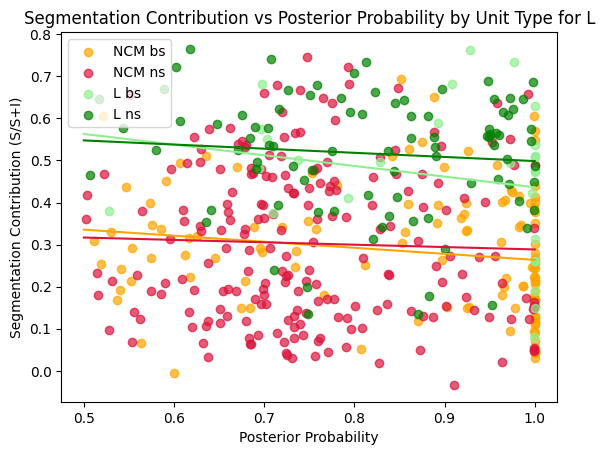

In [25]:
np.sum(idx_model_NCM_bs)
n_NCM_ns = np.sum(idx_model_NCM_ns)

df_model = pd.DataFrame({
    'performance_ratio': r2Segs[idx_model]/r2segIds[idx_model],
    'unit_type': unit_types[idx_model],
    'brain_area': brain_areas[idx_model],
    'rate': rate[idx_model],
    'posterior' : unit_type_probs[idx_model]
})

# Test in NCM only
model_full = smf.ols('performance_ratio ~ unit_type*posterior', data=df_model.loc[df_model['brain_area'] == 'NCM']).fit()
print(model_full.summary())


labels = ['L_bs', 'NCM_bs', 'L_ns', 'NCM_ns']
colors = ['lightgreen', 'orange', 'green', 'crimson']

plt.scatter(unit_type_probs[idx_model_NCM_bs], (r2Segs[idx_model_NCM_bs])/r2segIds[idx_model_NCM_bs], c = colors[1], alpha=0.7, label='NCM bs')
plt.scatter(unit_type_probs[idx_model_NCM_ns], (r2Segs[idx_model_NCM_ns])/r2segIds[idx_model_NCM_ns], c = colors[3], alpha=0.7, label='NCM ns')  
b0_bs = model_full.params['Intercept'] 
b1_bs = model_full.params['posterior']
b0_ns = model_full.params['Intercept'] + model_full.params['unit_type[T.ns]']
b1_ns = model_full.params['posterior'] + model_full.params['unit_type[T.ns]:posterior']
x = np.linspace(0.5, 1, 100)
y_bs = b0_bs + b1_bs * x
y_ns = b0_ns + b1_ns * x
plt.plot(x, y_bs, color=colors[1])
plt.plot(x, y_ns, color=colors[3])
plt.xlabel('Posterior Probability')
plt.ylabel('Segmentation Contribution (S/S+I)')
plt.title('Segmentation Contribution vs Posterior Probability by Unit Type for NCM')

# Test in L only
model_full = smf.ols('performance_ratio ~ unit_type*posterior', data=df_model.loc[df_model['brain_area'] == 'L']).fit()
print(model_full.summary()) 
plt.scatter(unit_type_probs[idx_model_L_bs], (r2Segs[idx_model_L_bs])/r2segIds[idx_model_L_bs], c = colors[0], alpha=0.7, label='L bs')
plt.scatter(unit_type_probs[idx_model_L_ns], (r2Segs[idx_model_L_ns])/r2segIds[idx_model_L_ns], c = colors[2], alpha=0.7, label='L ns')  
b0_bs = model_full.params['Intercept']
b1_bs = model_full.params['posterior']
b0_ns = model_full.params['Intercept'] + model_full.params['unit_type[T.ns]']
b1_ns = model_full.params['posterior'] + model_full.params['unit_type[T.ns]:posterior']
x = np.linspace(0.5, 1, 100)
y_bs = b0_bs + b1_bs * x
y_ns = b0_ns + b1_ns * x
plt.plot(x, y_bs, color=colors[0])
plt.plot(x, y_ns, color=colors[2])
plt.xlabel('Posterior Probability')
plt.ylabel('Segmentation Contribution (S/S+I)')
plt.legend()
plt.title('Segmentation Contribution vs Posterior Probability by Unit Type for L')

There might be a little missclassification with bs being assigned to ns but the effect is small (not statstically significant)

### The difference in Performance ratio between unit types cannot just be explained by differences in rates.
The statistics in the main text.  

LR statistic for Brain area effect: 104.98994159254767 with p-value 1.2275740412394723e-24 and df difference 1.0
                            OLS Regression Results                            
Dep. Variable:      performance_ratio   R-squared:                       0.250
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     74.30
Date:                Mon, 17 Aug 2026   Prob (F-statistic):           1.42e-28
Time:                        14:40:26   Log-Likelihood:                 172.96
No. Observations:                 449   AIC:                            -339.9
Df Residuals:                     446   BIC:                            -327.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-----------

Text(0.5, 1.0, 'Segmentation Contribution vs Firing Rate')

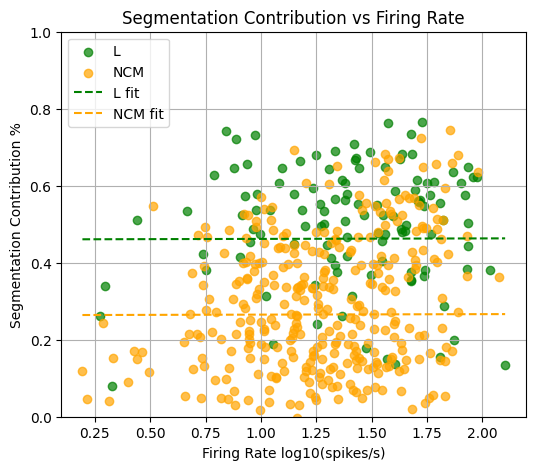

In [26]:
# Look at regression between Performance Ratio and Firing Rate and cell type
# Perform linear regression with interaction between rate and cell type

model_full = smf.ols('performance_ratio ~ rate * brain_area', data=df_model).fit()
model_area = smf.ols('performance_ratio ~ rate + brain_area', data=df_model).fit()
model_rate = smf.ols('performance_ratio ~ rate', data=df_model).fit()

lr_statistic, p_value, df_diff = model_area.compare_lr_test(model_rate)
print(f"LR statistic for Brain area effect: {lr_statistic} with p-value {p_value} and df difference {df_diff}")
print(model_area.summary())

lr_statistic, p_value, df_diff = model_full.compare_lr_test(model_area)
print(f"LR statistic for Interaction effect: {lr_statistic} with p-value {p_value} and df difference {df_diff}")
print(model_full.summary())

plt.figure(figsize=(6, 5))
idx_model_L = idx_model_L_bs | idx_model_L_ns
idx_model_NCM = idx_model_NCM_bs | idx_model_NCM_ns

plt.scatter(np.log10(rate[idx_model_L]), (r2Segs[idx_model_L])/r2segIds[idx_model_L], c = 'green', alpha=0.7, label='L')
plt.scatter(np.log10(rate[idx_model_NCM]), (r2Segs[idx_model_NCM])/r2segIds[idx_model_NCM], c = 'orange', alpha=0.7, label='NCM')  
b0_bs = model_area.params['Intercept'] 
b1_bs = model_area.params['rate']
b0_ns = model_area.params['Intercept'] + model_area.params['brain_area[T.NCM]']
b1_ns = model_area.params['rate']
x_fit = np.linspace(np.log10(rate[idx_model].min()), np.log10(rate[idx_model].max()), 100)
y_fit_bs = b0_bs + b1_bs * x_fit
y_fit_ns = b0_ns + b1_ns * x_fit
plt.plot(x_fit, y_fit_bs, color='green', linestyle='--', label='L fit')
plt.plot(x_fit, y_fit_ns, color='orange', linestyle='--', label='NCM fit')
plt.xlabel('Firing Rate log10(spikes/s)')
plt.ylabel('Segmentation Contribution %')
plt.ylim((0.0, 1.0))
plt.legend()
plt.grid(True)
plt.title('Segmentation Contribution vs Firing Rate')






### Comparison with STRF predictions.
The S+I models are better than STRF models always.
The S models overal are not better BUT the S models are better for segmentation units than STRF alone but STRF models are better for S units than for S+I units.
FOr S+I units, the STRF model is particularly poor even if it is better than the S model alone.

For all these reasons the S+I model is far superior than the STRF model.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


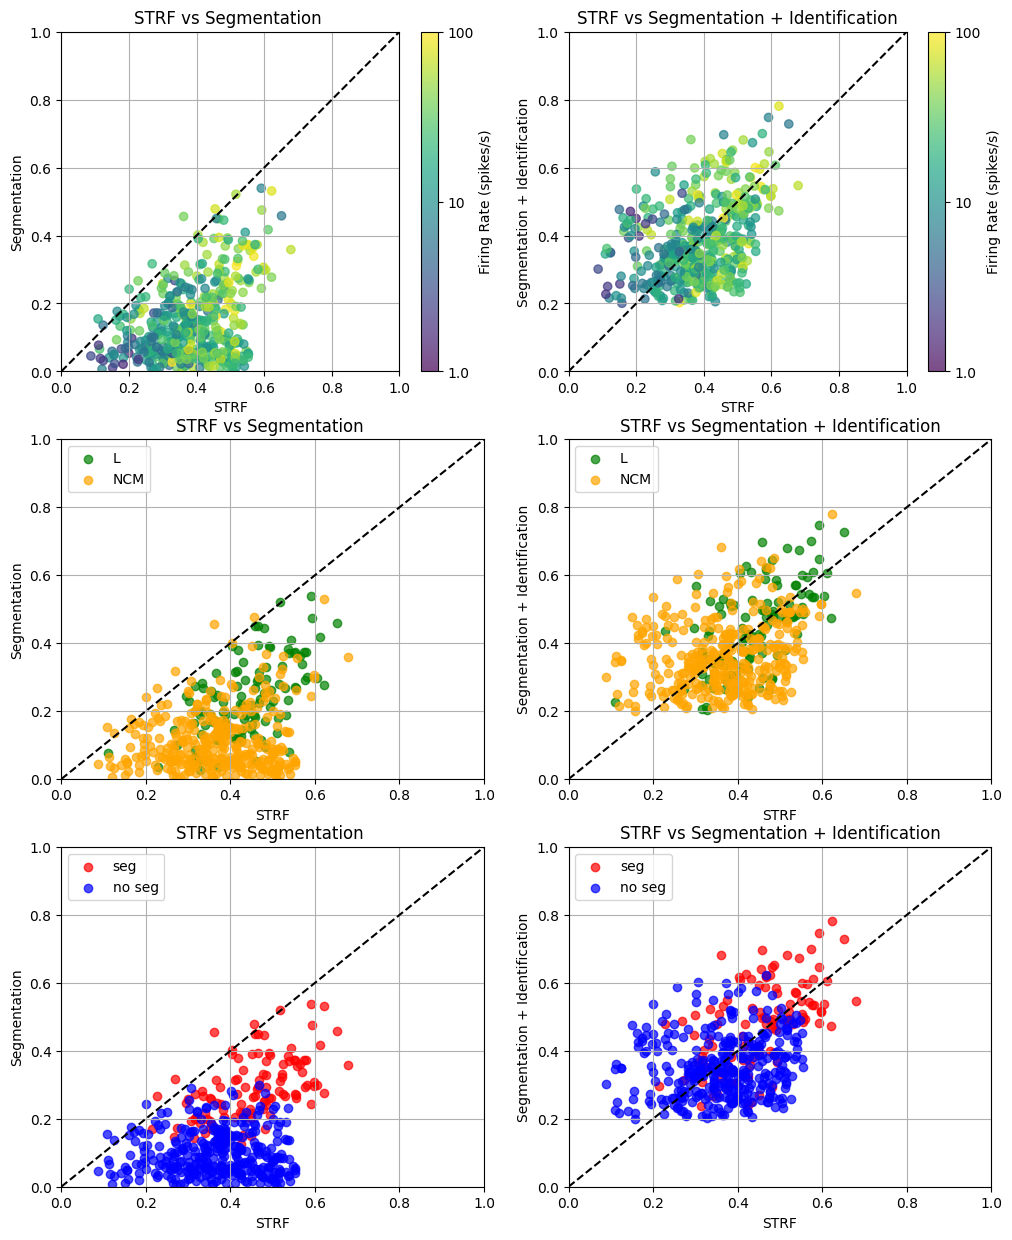

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


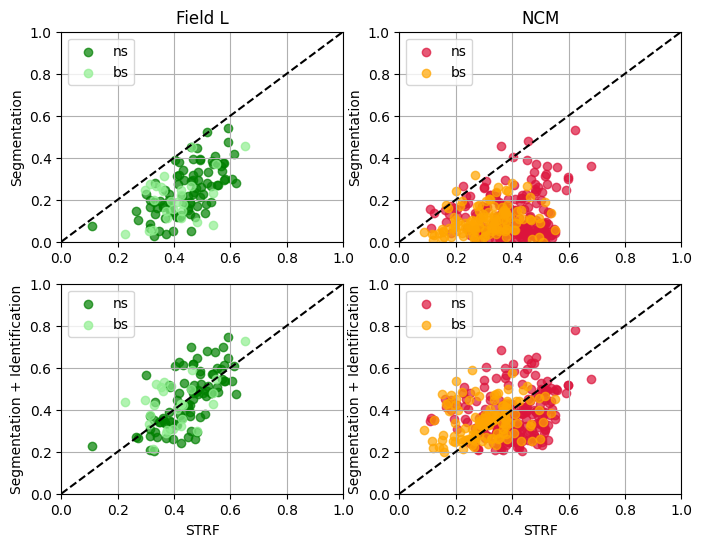

----------Comparing STRF and S and S+I models ----------

S Model vs STRF Performance: STRF 0.39 +- 0.005, Seg 0.15 +- 0.005
Difference: STRF - Segmentation: 0.241 ES : 1.937
Paired t-test between STRF and Segmentation: t(448) = 40.995, p-value = 1.05e-153

S+I Model vs STRF Performance: STRF 0.39 +- 0.005, S+I 0.38 +- 0.005
DIfference: STRF - S+I: 0.002 ES: 0.016
Paired t-test between STRF and S+I: t(448) = 0.331, p-value = 0.741

------------Results for L vs NCM:--------
---------------L Units----------------
S Model vs STRF Performance: STRF 0.44 +- 0.009, S+I 0.44 +- 0.012
Difference: STRF - S+I: -0.007 ES : -0.065
Paired t-test between STRF and S+I for L: t(115) = -0.692, p-value = 0.49
---------------NCM Units----------------
S+I Model vs STRF Performance: STRF 0.44 +- 0.009, S+I 0.36 +- 0.006
Difference: STRF - S+I: 0.073 ES: 0.558
Paired t-test between STRF and S+I for NCM: t(332) = 0.679, p-value = 0.498

------------Results for Segmentation-predicted inits:--------

S Model v

In [27]:
plt.figure(figsize=(12, 15))
plt.subplot(3,2,1)
plt.scatter(r2STRFs[idx_model]/r2Ceils[idx_model], r2Segs[idx_model]/r2Ceils[idx_model], c = np.log10(rate[idx_model]), cmap ='viridis', alpha=0.7, clim=(np.log10(rate_threshold), 2.0))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('STRF vs Segmentation ')
plt.xlabel('STRF')
plt.ylabel('Segmentation')
cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(3,2,2)
plt.scatter(r2STRFs[idx_model]/r2Ceils[idx_model], r2segIds[idx_model]/r2Ceils[idx_model], c = np.log10(rate[idx_model]), cmap ='viridis', alpha=0.7, clim=(np.log10(rate_threshold), 2.0))
plt.plot([0, 1], [0, 1], 'k--')
plt.title('STRF vs Segmentation + Identification')
plt.xlabel('STRF')
plt.ylabel('Segmentation + Identification')
cbar = plt.colorbar(label='Firing Rate (spikes/s)')
tickvalues = cbar.get_ticks()
cbar.set_ticks([np.log10(rate_threshold), 1.0, 2.0])
cbar.set_ticklabels([rate_threshold, 10, 100])
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(3,2,3)
plt.scatter(r2STRFs[idx_model_L]/r2Ceils[idx_model_L], r2Segs[idx_model_L]/r2Ceils[idx_model_L], c = 'green', alpha=0.7, label='L')
plt.scatter(r2STRFs[idx_model_NCM]/r2Ceils[idx_model_NCM], r2Segs[idx_model_NCM]/r2Ceils[idx_model_NCM], c = 'orange', alpha=0.7, label='NCM')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('STRF vs Segmentation ')
plt.xlabel('STRF')
plt.ylabel('Segmentation')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(3,2,4)
plt.scatter(r2STRFs[idx_model_L]/r2Ceils[idx_model_L], r2segIds[idx_model_L]/r2Ceils[idx_model_L], c = 'green', alpha=0.7, label='L')
plt.scatter(r2STRFs[idx_model_NCM]/r2Ceils[idx_model_NCM], r2segIds[idx_model_NCM]/r2Ceils[idx_model_NCM], c = 'orange', alpha=0.7, label='NCM')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('STRF vs Segmentation + Identification')
plt.xlabel('STRF')
plt.ylabel('Segmentation + Identification')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

seg_idx = idx_model & ((r2Segs/r2segIds) > 0.5)
noseg_idx = idx_model & ((r2Segs/r2segIds) <= 0.5)

plt.subplot(3,2,5)
plt.scatter(r2STRFs[seg_idx]/r2Ceils[seg_idx], r2Segs[seg_idx]/r2Ceils[seg_idx], c = 'red', alpha=0.7, label='seg')
plt.scatter(r2STRFs[noseg_idx]/r2Ceils[noseg_idx], r2Segs[noseg_idx]/r2Ceils[noseg_idx], c = 'blue', alpha=0.7, label='no seg')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('STRF vs Segmentation ')
plt.xlabel('STRF')
plt.ylabel('Segmentation')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(3,2,6)
plt.scatter(r2STRFs[seg_idx]/r2Ceils[seg_idx], r2segIds[seg_idx]/r2Ceils[seg_idx], c = 'red', alpha=0.7, label='seg')
plt.scatter(r2STRFs[noseg_idx]/r2Ceils[noseg_idx], r2segIds[noseg_idx]/r2Ceils[noseg_idx], c = 'blue', alpha=0.7, label='no seg')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('STRF vs Segmentation + Identification')
plt.xlabel('STRF')
plt.ylabel('Segmentation + Identification')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)
plt.savefig('/Users/frederictheunissen/Desktop/STRFvsSEGID.eps', dpi=300)
plt.show()

idx_model_L_bs = L_bs_idx & model_idx
idx_model_L_ns = L_ns_idx & model_idx
idx_model_NCM_bs = NCM_bs_idx & model_idx
idx_model_NCM_ns = NCM_ns_idx & model_idx

plt.figure(figsize=(8, 6))
plt.subplot(2,2,1)
plt.scatter(r2STRFs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2Segs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], c ='green', alpha=0.7, label='ns')
plt.scatter(r2STRFs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2Segs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], c = 'lightgreen', alpha=0.7, label='bs')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Field L')
#plt.xlabel('STRF')
plt.ylabel('Segmentation')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(2,2,2)
plt.scatter(r2STRFs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], r2Segs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], c ='crimson', alpha=0.7, label='ns')
plt.scatter(r2STRFs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2Segs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], c = 'orange', alpha=0.7, label='bs')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('NCM')
#plt.xlabel('STRF')
plt.ylabel('Segmentation')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(2,2,3)
plt.scatter(r2STRFs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2segIds[idx_model_L_ns]/r2Ceils[idx_model_L_ns], c ='green', alpha=0.7, label='ns')
plt.scatter(r2STRFs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2segIds[idx_model_L_bs]/r2Ceils[idx_model_L_bs], c = 'lightgreen', alpha=0.7, label='bs')
plt.plot([0, 1], [0, 1], 'k--')
#plt.title('Field L')
plt.xlabel('STRF')
plt.ylabel('Segmentation + Identification')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(2,2,4)
plt.scatter(r2STRFs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], r2segIds[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], c ='crimson', alpha=0.7, label='ns')
plt.scatter(r2STRFs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2segIds[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], c = 'orange', alpha=0.7, label='bs')
plt.plot([0, 1], [0, 1], 'k--')
#plt.title('NCM')
plt.xlabel('STRF')
plt.ylabel('Segmentation + Identification')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)
plt.savefig('/Users/frederictheunissen/Desktop/STRF_vs_SegID_L_NCM.eps', dpi=300)

plt.show()

# Statistical tests
print("----------Comparing STRF and S and S+I models ----------")
print()
t_stat = stats.ttest_rel(r2STRFs[idx_model]/r2Ceils[idx_model], r2Segs[idx_model]/r2Ceils[idx_model])
mean_STRF = np.mean(r2STRFs[idx_model]/r2Ceils[idx_model])
sem_STRF = np.std(r2STRFs[idx_model]/r2Ceils[idx_model])/np.sqrt(len(r2STRFs[idx_model]/r2Ceils[idx_model]))
mean_Seg = np.mean(r2Segs[idx_model]/r2Ceils[idx_model])
sem_Seg = np.std(r2Segs[idx_model]/r2Ceils[idx_model])/np.sqrt(len(r2Segs[idx_model]/r2Ceils[idx_model]))
delta_mean = mean_STRF - mean_Seg
delta_sd = np.sqrt(np.var((r2STRFs[idx_model]- r2Segs[idx_model])/r2Ceils[idx_model]))
ES = delta_mean / delta_sd
print(f"S Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, Seg {mean_Seg:.2f} +- {sem_Seg:.3f}")
print(f"Difference: STRF - Segmentation: {delta_mean:.3f} ES : {ES:.3f}")
print(f"Paired t-test between STRF and Segmentation: t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")

t_stat = stats.ttest_rel(r2STRFs[idx_model]/r2Ceils[idx_model], r2segIds[idx_model]/r2Ceils[idx_model])
mean_SI = np.mean(r2segIds[idx_model]/r2Ceils[idx_model])
sem_SI = np.std(r2segIds[idx_model]/r2Ceils[idx_model])/np.sqrt(len(r2segIds[idx_model]/r2Ceils[idx_model]))
delta_mean = mean_STRF - mean_SI
delta_sd = np.sqrt(np.var((r2STRFs[idx_model]- r2segIds[idx_model])/r2Ceils[idx_model]))
ES = delta_mean / delta_sd
print()
print(f"S+I Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S+I {mean_SI:.2f} +- {sem_SI:.3f}")
print(f"DIfference: STRF - S+I: {delta_mean:.3f} ES: {ES:.3f}")
print(f"Paired t-test between STRF and S+I: t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")

# Repeat for L vs NCM
print()
print("------------Results for L vs NCM:--------")
t_stat = stats.ttest_rel(r2STRFs[idx_model_L]/r2Ceils[idx_model_L], r2segIds[idx_model_L]/r2Ceils[idx_model_L])
mean_STRF = np.mean(r2STRFs[idx_model_L]/r2Ceils[idx_model_L])
sem_STRF = np.std(r2STRFs[idx_model_L]/r2Ceils[idx_model_L])/np.sqrt(len(r2STRFs[idx_model_L]/r2Ceils[idx_model_L]))
mean_SI = np.mean(r2segIds[idx_model_L]/r2Ceils[idx_model_L])
sem_SI = np.std(r2segIds[idx_model_L]/r2Ceils[idx_model_L])/np.sqrt(len(r2segIds[idx_model_L]/r2Ceils[idx_model_L]))
delta_mean = mean_STRF - mean_SI
delta_sd = np.sqrt(np.var((r2STRFs[idx_model_L]- r2segIds[idx_model_L])/r2Ceils[idx_model_L]))
ES = delta_mean / delta_sd
print("---------------L Units----------------")
print(f"S Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S+I {mean_SI:.2f} +- {sem_SI:.3f}")
print(f"Difference: STRF - S+I: {delta_mean:.3f} ES : {ES:.3f}")
print(f"Paired t-test between STRF and S+I for L: t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")

t_stat = stats.ttest_rel(r2STRFs[idx_model_NCM]/r2Ceils[idx_model_NCM], r2segIds[idx_model_NCM]/r2Ceils[idx_model_NCM])
mean_SI = np.mean(r2segIds[idx_model_NCM]/r2Ceils[idx_model_NCM])
sem_SI = np.std(r2segIds[idx_model_NCM]/r2Ceils[idx_model_NCM])/np.sqrt(len(r2segIds[idx_model_NCM]/r2Ceils[idx_model_NCM]))
delta_mean = mean_STRF - mean_SI
delta_sd = np.sqrt(np.var((r2STRFs[idx_model_NCM]- r2segIds[idx_model_NCM])/r2Ceils[idx_model_NCM]))
ES = delta_mean / delta_sd
print("---------------NCM Units----------------")
print(f"S+I Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S+I {mean_SI:.2f} +- {sem_SI:.3f}")
print(f"Difference: STRF - S+I: {delta_mean:.3f} ES: {ES:.3f}")
print(f"Paired t-test between STRF and S+I for NCM: t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")

# Repeat for segmentation-predicted vs non-segmentation predicted units
print()
print("------------Results for Segmentation-predicted inits:--------")
t_stat = stats.ttest_rel(r2STRFs[seg_idx]/r2Ceils[seg_idx], r2Segs[seg_idx]/r2Ceils[seg_idx])   
mean_STRF = np.mean(r2STRFs[seg_idx]/r2Ceils[seg_idx])
sem_STRF = np.std(r2STRFs[seg_idx]/r2Ceils[seg_idx])/np.sqrt(len(r2STRFs[seg_idx]/r2Ceils[seg_idx]))
mean_Seg = np.mean(r2Segs[seg_idx]/r2Ceils[seg_idx])
sem_Seg = np.std(r2Segs[seg_idx]/r2Ceils[seg_idx])/np.sqrt(len(r2Segs[seg_idx]/r2Ceils[seg_idx]))
delta_mean = mean_STRF - mean_Seg
delta_sd = np.sqrt(np.var((r2STRFs[seg_idx]- r2Segs[seg_idx])/r2Ceils[seg_idx]))
ES = delta_mean / delta_sd
print()
print(f"S Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S {mean_Seg:.2f} +- {sem_Seg:.3f}")
print(f"Difference: STRF - Segmentation: {delta_mean:.3f} ES : {ES:.3f}")
print(f"Paired t-test between STRF and Segmentation for Segmented Units: t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")

t_stat = stats.ttest_rel(r2STRFs[seg_idx]/r2Ceils[seg_idx], r2segIds[seg_idx]/r2Ceils[seg_idx]) 
mean_SI = np.mean(r2segIds[seg_idx]/r2Ceils[seg_idx])
sem_SI = np.std(r2segIds[seg_idx]/r2Ceils[seg_idx])/np.sqrt(len(r2segIds[seg_idx]/r2Ceils[seg_idx]))
delta_mean = mean_STRF - mean_SI
delta_sd = np.sqrt(np.var((r2STRFs[seg_idx]- r2segIds[seg_idx])/r2Ceils[seg_idx]))
ES = delta_mean / delta_sd  
print()
print(f"S + I Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S {mean_SI:.2f} +- {sem_SI:.3f}")
print(f"Difference: STRF - S+I: {delta_mean:.3f} ES: {ES:.3f}")
print(f"Paired t-test between STRF and S+I : t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")
print()

print("------------Results for non Segmentation-predicted inits:--------")
print()
t_stat = stats.ttest_rel(r2STRFs[noseg_idx]/r2Ceils[noseg_idx], r2Segs[noseg_idx]/r2Ceils[noseg_idx])  
mean_STRF = np.mean(r2STRFs[noseg_idx]/r2Ceils[noseg_idx])
sem_STRF = np.std(r2STRFs[noseg_idx]/r2Ceils[noseg_idx])/np.sqrt(len(r2STRFs[noseg_idx]/r2Ceils[noseg_idx]))
mean_Seg = np.mean(r2Segs[noseg_idx]/r2Ceils[noseg_idx])
sem_Seg = np.std(r2Segs[noseg_idx]/r2Ceils[noseg_idx])/np.sqrt(len(r2Segs[noseg_idx]/r2Ceils[noseg_idx]))
delta_mean = mean_STRF - mean_Seg
delta_sd = np.sqrt(np.var((r2STRFs[noseg_idx]- r2Segs[noseg_idx])/r2Ceils[noseg_idx]))
ES = delta_mean / delta_sd 
print(f"S Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S {mean_Seg:.2f} +- {sem_Seg:.3f}")
print(f"Difference: STRF - Segmentation: {delta_mean:.3f} ES : {ES:.3f}")
print(f"Paired t-test between STRF and Segmentation : t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")
print()


t_stat = stats.ttest_rel(r2STRFs[noseg_idx]/r2Ceils[noseg_idx], r2segIds[noseg_idx]/r2Ceils[noseg_idx])
mean_SI = np.mean(r2segIds[noseg_idx]/r2Ceils[noseg_idx])
sem_SI = np.std(r2segIds[noseg_idx]/r2Ceils[noseg_idx])/np.sqrt(len(r2segIds[noseg_idx]/r2Ceils[noseg_idx]))
delta_mean = mean_STRF - mean_SI
delta_sd = np.sqrt(np.var((r2STRFs[noseg_idx]- r2segIds[noseg_idx])/r2Ceils[noseg_idx]))
ES = delta_mean / delta_sd
print(f"S + I Model vs STRF Performance: STRF {mean_STRF:.2f} +- {sem_STRF:.3f}, S {mean_SI:.2f} +- {sem_SI:.3f}")
print(f"Difference: STRF - S+I: {delta_mean:.3f} ES: {ES:.3f}")
print(f"Paired t-test between STRF and S+I : t({t_stat.df}) = {t_stat.statistic:.3f}, p-value = {t_stat.pvalue:.3g}")

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


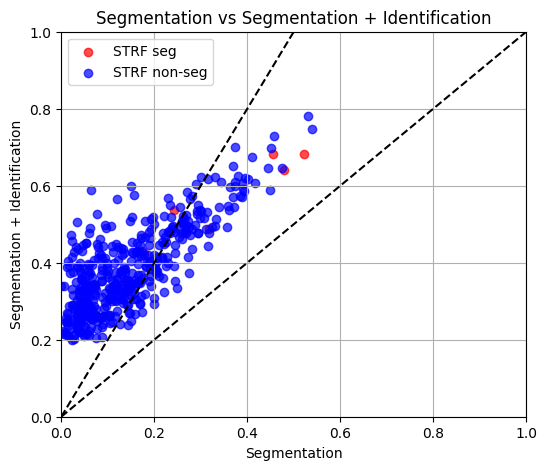

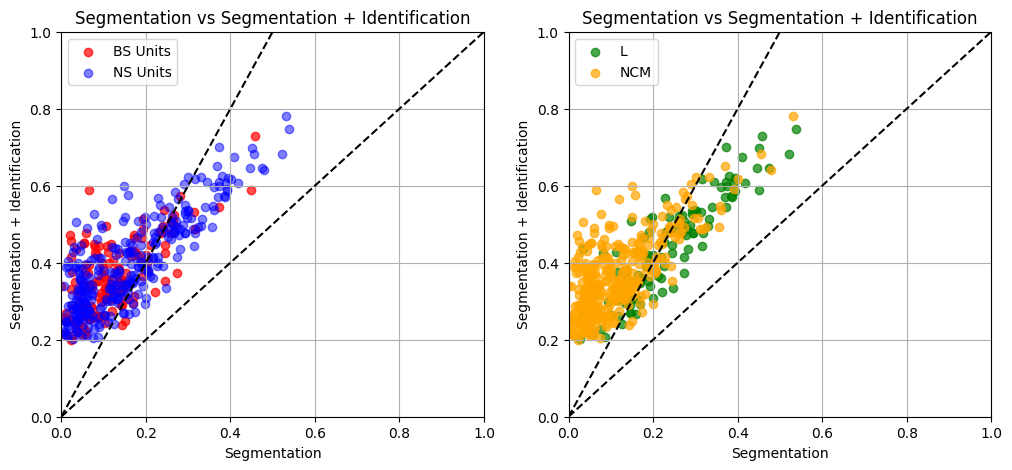

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


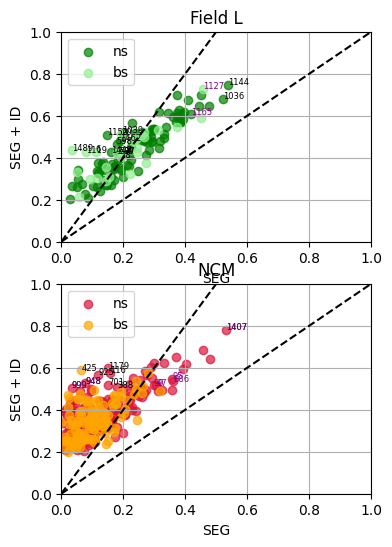

Good L Segmentation Units:  [1036, 1144]
Good L Segmentation + Identification Units:  [3, 6, 20, 28, 39, 597, 598, 1039, 1119, 1150, 1445, 1462, 1489]
Good L STRF Units:  [1127, 1165]
Good NCM Segmentation Units:  [1407]
Good NCM Segmentation + Identification Units:  [116, 388, 425, 701, 925, 948, 999, 1179]
Good NCM STRF Units:  [90, 95, 97, 886, 948, 999, 1407]


In [28]:
# I thought that comparing segmentation performance to STRF performance could be good way to determine segmentaiton only units but only kind of works.
# There are clearly segmentation + indentification units that are poorly moodeled with STRFs as well.

strfseg_idx = idx_model & (r2STRFs <= 1*r2Segs)
strfnoseg_idx = idx_model & (r2STRFs > 1*r2Segs)

plt.figure(figsize=(6, 5))
plt.scatter(r2Segs[strfseg_idx]/r2Ceils[strfseg_idx], r2segIds[strfseg_idx]/r2Ceils[strfseg_idx], c = 'red', alpha=0.7, label='STRF seg')
plt.scatter(r2Segs[strfnoseg_idx]/r2Ceils[strfnoseg_idx], r2segIds[strfnoseg_idx]/r2Ceils[strfnoseg_idx], c = 'blue', alpha=0.7, label='STRF non-seg')

plt.plot([0, 1], [0, 1], 'k--')
plt.plot([0, 1], [0, 2.0], 'k--')
plt.title('Segmentation vs Segmentation + Identification')
plt.xlabel('Segmentation')
plt.ylabel('Segmentation + Identification')
plt.legend(['Seg Units', 'SegID Units'])
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.legend()
plt.grid(True)

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
bs_idx = idx_model & (unit_types == 'bs')
ns_idx = idx_model & (unit_types == 'ns')
plt.scatter(r2Segs[bs_idx]/r2Ceils[bs_idx], r2segIds[bs_idx]/r2Ceils[bs_idx], c ='red', alpha=0.7)
plt.scatter(r2Segs[ns_idx]/r2Ceils[ns_idx], r2segIds[ns_idx]/r2Ceils[ns_idx], c = 'blue', alpha=0.5)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot([0, 1], [0, 2.0], 'k--')
plt.title('Segmentation vs Segmentation + Identification')
plt.xlabel('Segmentation')
plt.ylabel('Segmentation + Identification')
plt.legend(['BS Units', 'NS Units'])
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(1,2,2)
plt.scatter(r2Segs[idx_model_L]/r2Ceils[idx_model_L], r2segIds[idx_model_L]/r2Ceils[idx_model_L], c ='green', alpha=0.7, label='L')
plt.scatter(r2Segs[idx_model_NCM]/r2Ceils[idx_model_NCM], r2segIds[idx_model_NCM]/r2Ceils[idx_model_NCM], c ='orange', alpha=0.7, label='NCM')
plt.plot([0, 1], [0, 1], 'k--')
plt.plot([0, 1], [0, 2.0], 'k--')
plt.title('Segmentation vs Segmentation + Identification')
plt.xlabel('Segmentation')
plt.ylabel('Segmentation + Identification')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)
plt.savefig('/Users/frederictheunissen/Desktop/Seg_vs_SegID_Unit_Areas.eps', dpi=300)

plt.show()

idx_model_L_bs = L_bs_idx & model_idx
idx_model_L_ns = L_ns_idx & model_idx
idx_model_NCM_bs = NCM_bs_idx & model_idx
idx_model_NCM_ns = NCM_ns_idx & model_idx

plt.figure(figsize=(4, 6))
plt.subplot(2,1,1)
plt.scatter(r2Segs[idx_model_L_ns]/r2Ceils[idx_model_L_ns], r2segIds[idx_model_L_ns]/r2Ceils[idx_model_L_ns], c ='green', alpha=0.7, label='ns')
plt.scatter(r2Segs[idx_model_L_bs]/r2Ceils[idx_model_L_bs], r2segIds[idx_model_L_bs]/r2Ceils[idx_model_L_bs], c = 'lightgreen', alpha=0.7, label='bs')
goodLSEG = []
goodLSEGID = []
goodLSTRF = []
for i in range(len(r2Segs)):
    if idx_model_L_ns[i] or idx_model_L_bs[i]:
        if idx_model[i] and ((r2Segs[i]/r2Ceils[i]) < 0.2) and ((r2segIds[i]/r2Ceils[i]) > 0.4):
            plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6)
            goodLSEGID.append(i)
        if idx_model[i] and ((r2Segs[i]/r2Ceils[i]) > 0.5) and ((r2segIds[i]/r2Ceils[i]) > 0.5) and ((r2Segs[i]/(r2segIds[i])) > 0.6):
            plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6) 
            goodLSEG.append(i)
        if idx_model[i] and ((r2STRFs[i]/r2Ceils[i]) > 0.6) and ((r2segIds[i]/r2Ceils[i]) >0.6):
            plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6, color='purple') 
            goodLSTRF.append(i)
        
plt.plot([0, 1], [0, 1], 'k--')
plt.plot([0, 1], [0, 2.0], 'k--')
plt.title('Field L')
plt.xlabel('SEG')
plt.ylabel('SEG + ID')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)

plt.subplot(2,1,2)
plt.scatter(r2Segs[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], r2segIds[idx_model_NCM_ns]/r2Ceils[idx_model_NCM_ns], c ='crimson', alpha=0.7, label='ns')
plt.scatter(r2Segs[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], r2segIds[idx_model_NCM_bs]/r2Ceils[idx_model_NCM_bs], c = 'orange', alpha=0.7, label='bs')
goodNCMSEG = []
goodNCMSEGID = []
goodNCMSTRF = []
for i in range(len(r2Segs)):
    if idx_model_NCM_ns[i] or idx_model_NCM_bs[i]:
        if idx_model[i] and ((r2Segs[i]/r2Ceils[i]) < 0.2) and ((r2segIds[i]/r2Ceils[i]) > 0.5):
            plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6)
            goodNCMSEGID.append(i)
        if idx_model[i] and ((r2Segs[i]/r2Ceils[i]) > 0.5) and ((r2segIds[i]/r2Ceils[i]) > 0.5) and ((r2Segs[i]/(r2segIds[i])) > 0.6):
            plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6)
            goodNCMSEG.append(i)
        if idx_model[i] and ((r2STRFs[i]/r2Ceils[i]) > 0.5) and ((r2segIds[i]/r2Ceils[i]) > 0.5):
            plt.text(r2Segs[i]/r2Ceils[i], r2segIds[i]/r2Ceils[i], f"{i}", fontsize=6, color='purple')
            goodNCMSTRF.append(i)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot([0, 1], [0, 2.0], 'k--')
plt.title('NCM')
plt.xlabel('SEG')
plt.ylabel('SEG + ID')
plt.legend()
plt.xlim((0.0, 1.0))
plt.ylim((0.0, 1.0))
plt.grid(True)
plt.savefig('/Users/frederictheunissen/Desktop/Seg_vs_SegID_L_NCM.eps', dpi=300)

plt.show()

print("Good L Segmentation Units: ", goodLSEG)
print("Good L Segmentation + Identification Units: ", goodLSEGID)
print("Good L STRF Units: ", goodLSTRF)
print("Good NCM Segmentation Units: ", goodNCMSEG)
print("Good NCM Segmentation + Identification Units: ", goodNCMSEGID)
print("Good NCM STRF Units: ", goodNCMSTRF)



In [29]:

print("Example segmentation-predicted units with high model prediction:")
print("\t Field L")
for i_unit in goodLSEG:
        print(f"Unit {i_unit} found in Bird {birds[i_unit]} - Region {brain_areas[i_unit]} - Unit ID {unit_ids[i_unit]} - Unit {units[i_unit]} - File: {nwbFiles[i_unit]}: SNR={snrs[i_unit]:.2f}, Info={infos[i_unit]:.2f}, Rate={rate[i_unit]:.2f}, Data Length={data_length[i_unit]/1000:.0f} s, R2seg={r2Segs[i_unit]/r2Ceils[i_unit]:.2f}, R2segID={r2segIds[i_unit]/r2Ceils[i_unit]:.2f}, Seg Unit {seg_idx[i_unit]}")

print("\t NCM")
for i_unit in goodNCMSEG:
        print(f"Unit {i_unit} found in Bird {birds[i_unit]} - Region {brain_areas[i_unit]} - Unit ID {unit_ids[i_unit]} - Unit {units[i_unit]} - File: {nwbFiles[i_unit]}: SNR={snrs[i_unit]:.2f}, Info={infos[i_unit]:.2f}, Rate={rate[i_unit]:.2f}, Data Length={data_length[i_unit]/1000:.0f} s, R2seg={r2Segs[i_unit]/r2Ceils[i_unit]:.2f}, R2segID={r2segIds[i_unit]/r2Ceils[i_unit]:.2f}, Seg Unit {seg_idx[i_unit]}")

print("Example segmentation + identification-predicted units with high model prediction:")
print("\t Field L")
for i_unit in goodLSEGID:
        print(f"Unit {i_unit} found in Bird {birds[i_unit]} - Region {brain_areas[i_unit]} - Unit ID {unit_ids[i_unit]} - Unit {units[i_unit]} - File: {nwbFiles[i_unit]}: SNR={snrs[i_unit]:.2f}, Info={infos[i_unit]:.2f}, Rate={rate[i_unit]:.2f}, Data Length={data_length[i_unit]/1000:.0f} s, R2seg={r2Segs[i_unit]/r2Ceils[i_unit]:.2f}, R2segID={r2segIds[i_unit]/r2Ceils[i_unit]:.2f}, Seg Unit {seg_idx[i_unit]}")
print("\t NCM")
for i_unit in goodNCMSEGID:
        print(f"Unit {i_unit} found in Bird {birds[i_unit]} - Region {brain_areas[i_unit]} - Unit ID {unit_ids[i_unit]} - Unit {units[i_unit]} - File: {nwbFiles[i_unit]}: SNR={snrs[i_unit]:.2f}, Info={infos[i_unit]:.2f}, Rate={rate[i_unit]:.2f}, Data Length={data_length[i_unit]/1000:.0f} s, R2seg={r2Segs[i_unit]/r2Ceils[i_unit]:.2f}, R2segID={r2segIds[i_unit]/r2Ceils[i_unit]:.2f}, Seg Unit {seg_idx[i_unit]}")


Example segmentation-predicted units with high model prediction:
	 Field L
Unit 1036 found in Bird XXXLbl116XF - Region L - Unit ID 7 - Unit 18 - File: XXXLbl116XF_site2_251017_130550_op_pb_ks4_lat_251102: SNR=0.33, Info=20.54, Rate=53.42, Data Length=1036 s, R2seg=0.52, R2segID=0.68, Seg Unit True
Unit 1144 found in Bird XXXLbl121XM - Region L - Unit ID 33 - Unit 87 - File: XXXLbl121XM_site2_251215_085247_op_pb_ks4_lat_260121: SNR=0.17, Info=6.80, Rate=7.70, Data Length=3062 s, R2seg=0.54, R2segID=0.75, Seg Unit True
	 NCM
Unit 1407 found in Bird XXXBlu121XF - Region NCM - Unit ID 137 - Unit 189 - File: XXXBlu121XF_site02_250117_074609_op_pb_ks4_lat_250215: SNR=2.41, Info=35.02, Rate=77.98, Data Length=2177 s, R2seg=0.53, R2segID=0.78, Seg Unit True
Example segmentation + identification-predicted units with high model prediction:
	 Field L
Unit 3 found in Bird XXXLbl116XF - Region L - Unit ID 3 - Unit 5 - File: XXXLbl116XF_site1_251017_075859_op_pb_ks4_lat_251102: SNR=0.51, Info=16.35

## Some summary statistics on the RFs of SEG neurons

In [30]:
print(f"Number of segmentation predicted units: {np.sum(seg_idx)}")

Number of segmentation predicted units: 111


In [31]:
birdRegions

{'BlaBla3736M': 'NCM',
 'BluBlu1312F': 'NCM?',
 'HpiPur2667F': 'NCM',
 'HpiRed7670F': 'NCM/Fiedl L',
 'OraGre4617M': 'NCM',
 'XXXBlu121XF': 'NCM?',
 'XXXLbl116XF': 'Field L',
 'XXXLbl121XM': 'Field L'}

-------------------------------BlaBla3736M-----------------------------


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

Onset unit numbers:
Unit 1075: 0.27
Offset unit numbers:
Other seg unit numbers:


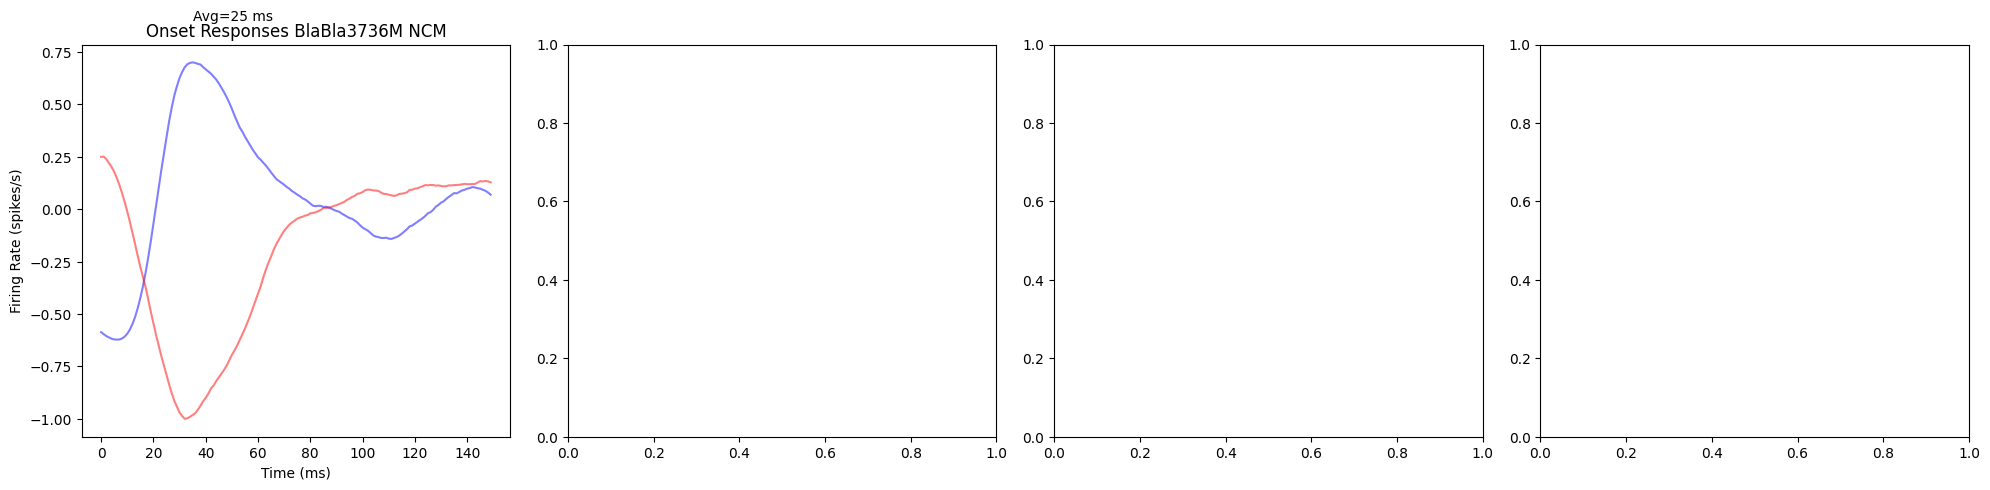

-------------------------------BluBlu1312F-----------------------------
Onset unit numbers:
Offset unit numbers:
Other seg unit numbers:


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

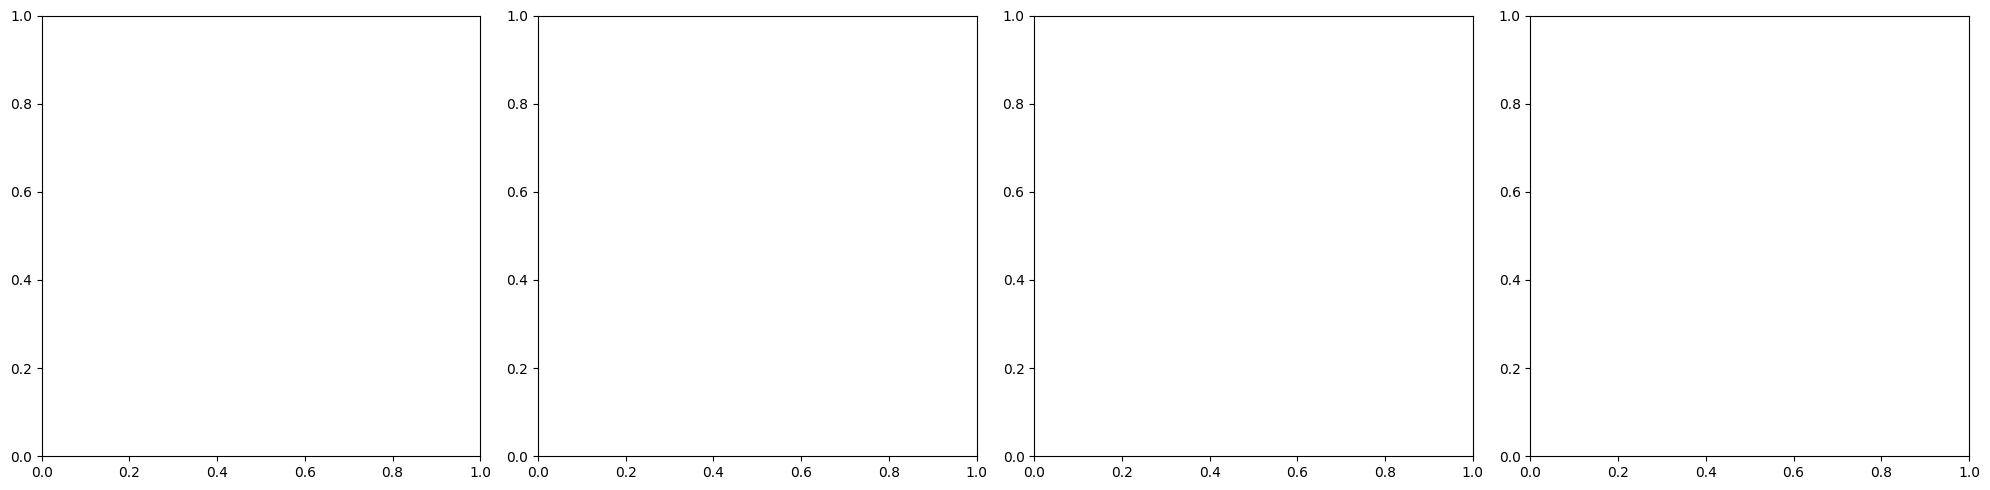

-------------------------------HpiPur2667F-----------------------------
Onset unit numbers:
Unit  494: 0.17
Unit  499: 0.32
Unit  501: 0.25
Unit  511: 0.20
Unit  516: 0.21
Unit  877: 0.20
Unit  880: 0.20
Unit  886: 0.36
Unit  889: 0.14
Unit  890: 0.31
Unit  919: 0.23
Offset unit numbers:
Other seg unit numbers:
Unit  495: 0.24
Unit  496: 0.20
Unit  878: 0.26
Unit  879: 0.23


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

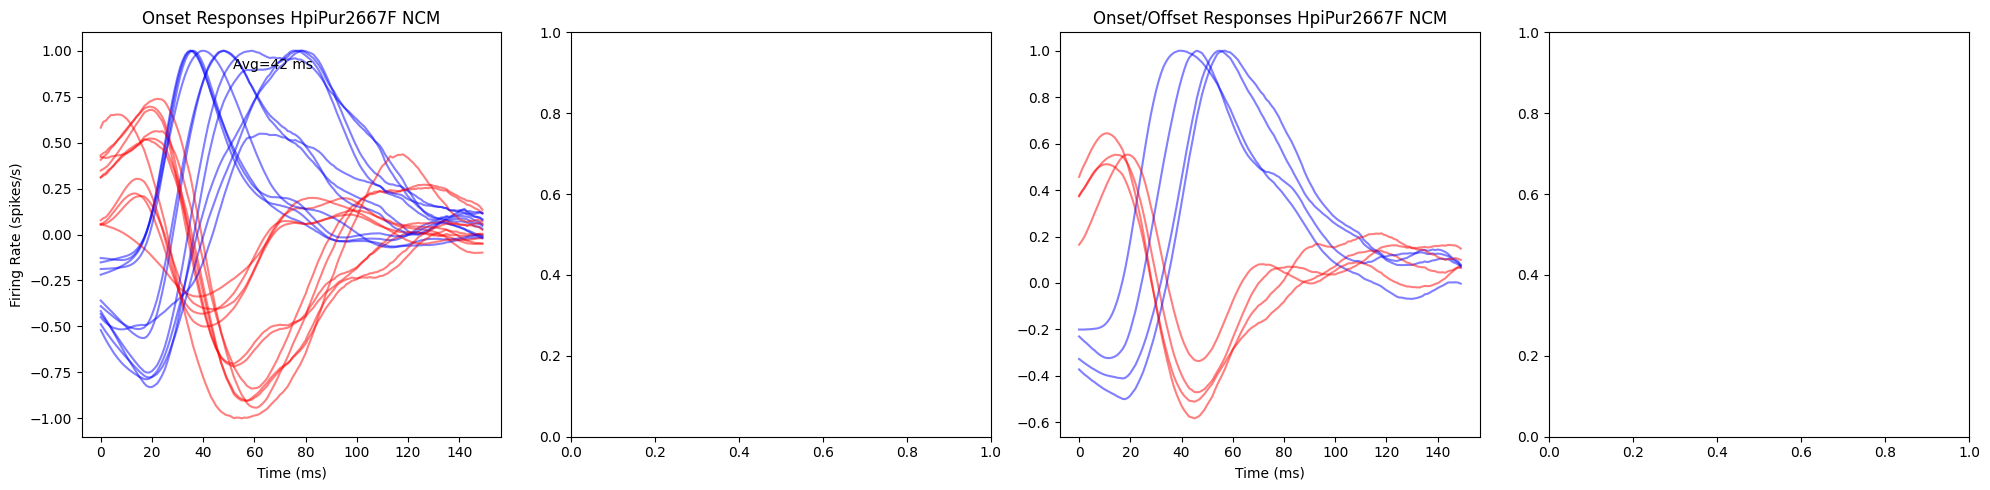

-------------------------------HpiRed7670F-----------------------------


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

Onset unit numbers:
Unit   52: 0.36
Unit   78: 0.26
Unit   90: 0.30
Unit   94: 0.24
Unit   95: 0.36
Unit   97: 0.31
Unit  104: 0.17
Unit  591: 0.36
Unit  592: 0.29
Unit  594: 0.27
Unit  595: 0.30
Unit  596: 0.27
Unit  599: 0.17
Unit  600: 0.21
Unit  607: 0.13
Unit  608: 0.28
Unit  609: 0.15
Unit  620: 0.22
Unit 1423: 0.37
Unit 1424: 0.22
Unit 1425: 0.34
Unit 1426: 0.33
Unit 1429: 0.29
Unit 1430: 0.31
Unit 1431: 0.48
Unit 1432: 0.19
Unit 1433: 0.27
Unit 1434: 0.37
Unit 1437: 0.23
Unit 1439: 0.25
Unit 1452: 0.29
Unit 1453: 0.37
Unit 1454: 0.24
Unit 1455: 0.32
Unit 1457: 0.37
Unit 1461: 0.38
Unit 1465: 0.25
Unit 1467: 0.26
Unit 1468: 0.15
Unit 1469: 0.19
Unit 1470: 0.33
Unit 1472: 0.29
Unit 1476: 0.30
Unit 1478: 0.22
Unit 1485: 0.28
Unit 1493: 0.16
Unit 1499: 0.27
Offset unit numbers:
Unit  133: 0.20
Unit  603: 0.27
Unit  611: 0.16
Other seg unit numbers:
Unit  606: 0.20
Unit  612: 0.15


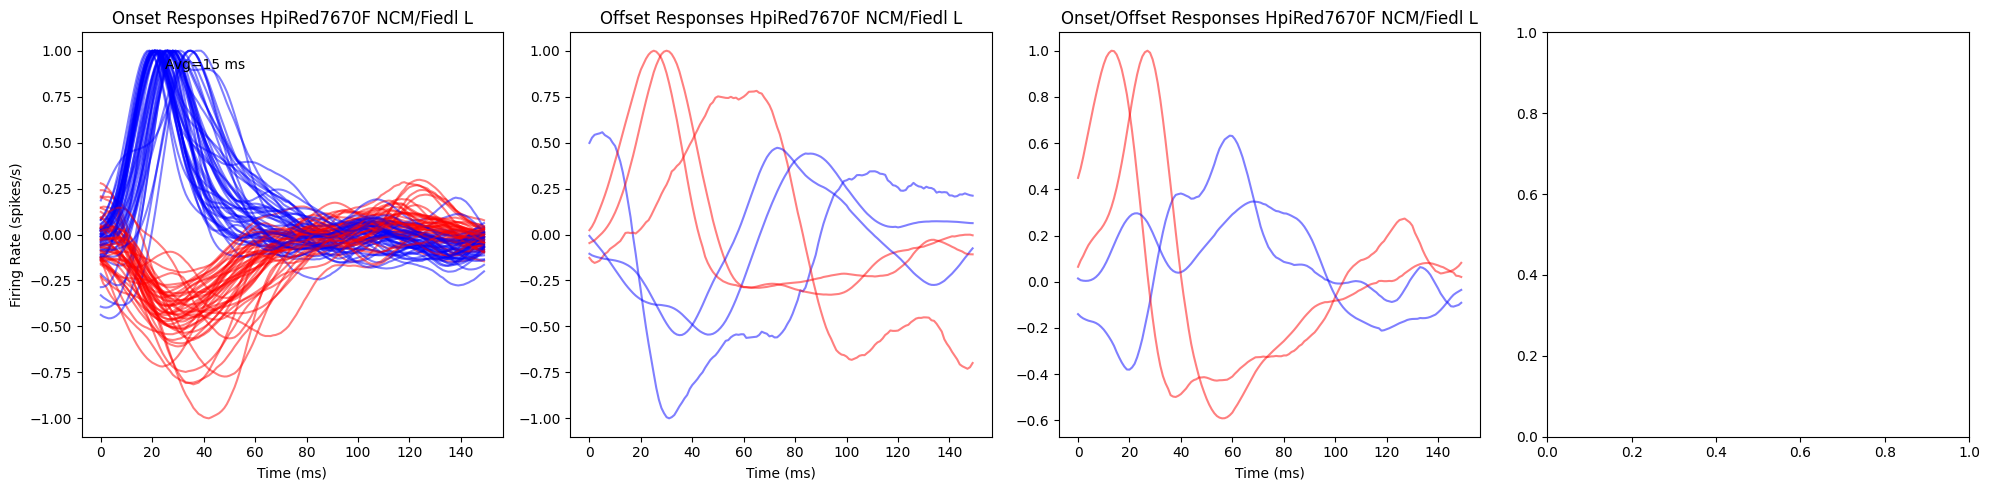

-------------------------------OraGre4617M-----------------------------


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

Onset unit numbers:
Unit  583: 0.22
Unit  705: 0.37
Offset unit numbers:
Other seg unit numbers:
Unit  372: 0.26
Unit  400: 0.32
Unit  409: 0.29
Unit  677: 0.39
Unit  684: 0.46
Unit  700: 0.27
Unit  732: 0.40


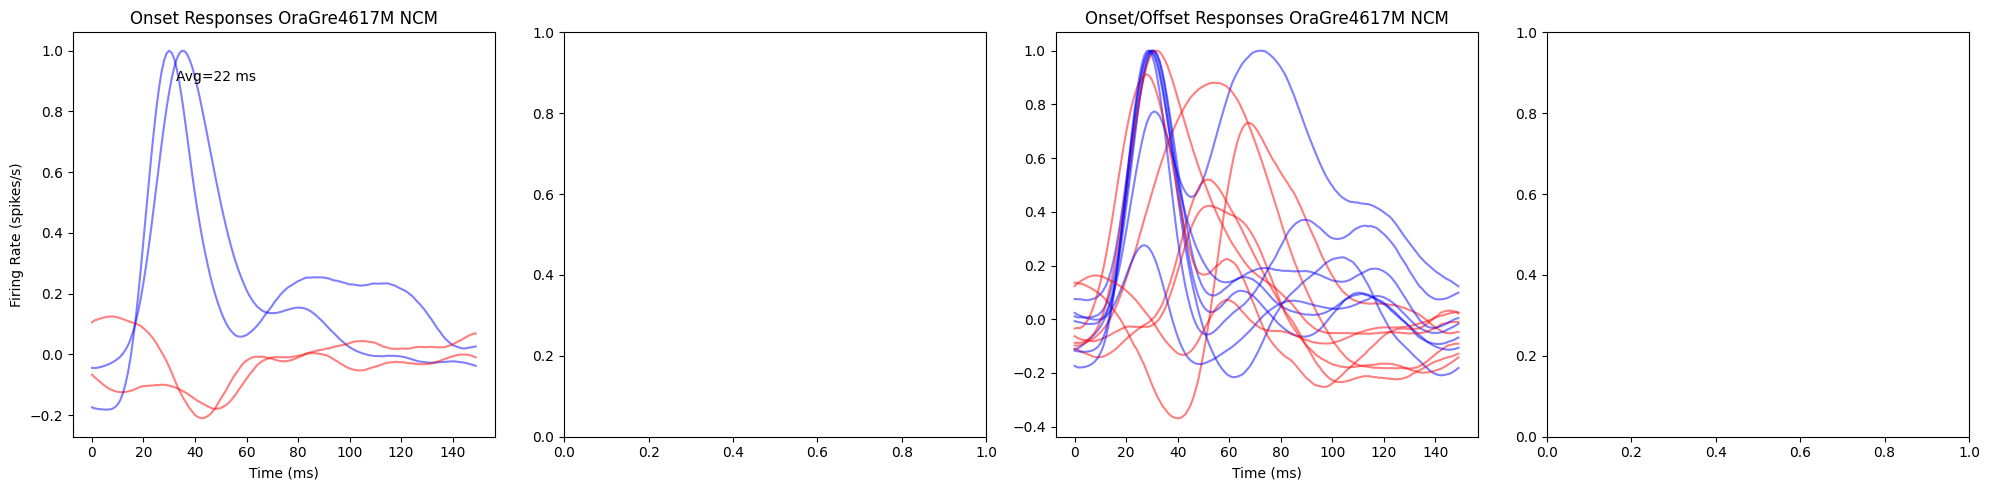

-------------------------------XXXBlu121XF-----------------------------


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

Onset unit numbers:
Unit  214: 0.15
Unit  238: 0.18
Unit  279: 0.21
Unit  303: 0.26
Unit  339: 0.24
Offset unit numbers:
Unit  350: 0.48
Unit 1294: 0.17
Unit 1321: 0.26
Unit 1355: 0.19
Unit 1405: 0.33
Unit 1407: 0.53
Other seg unit numbers:


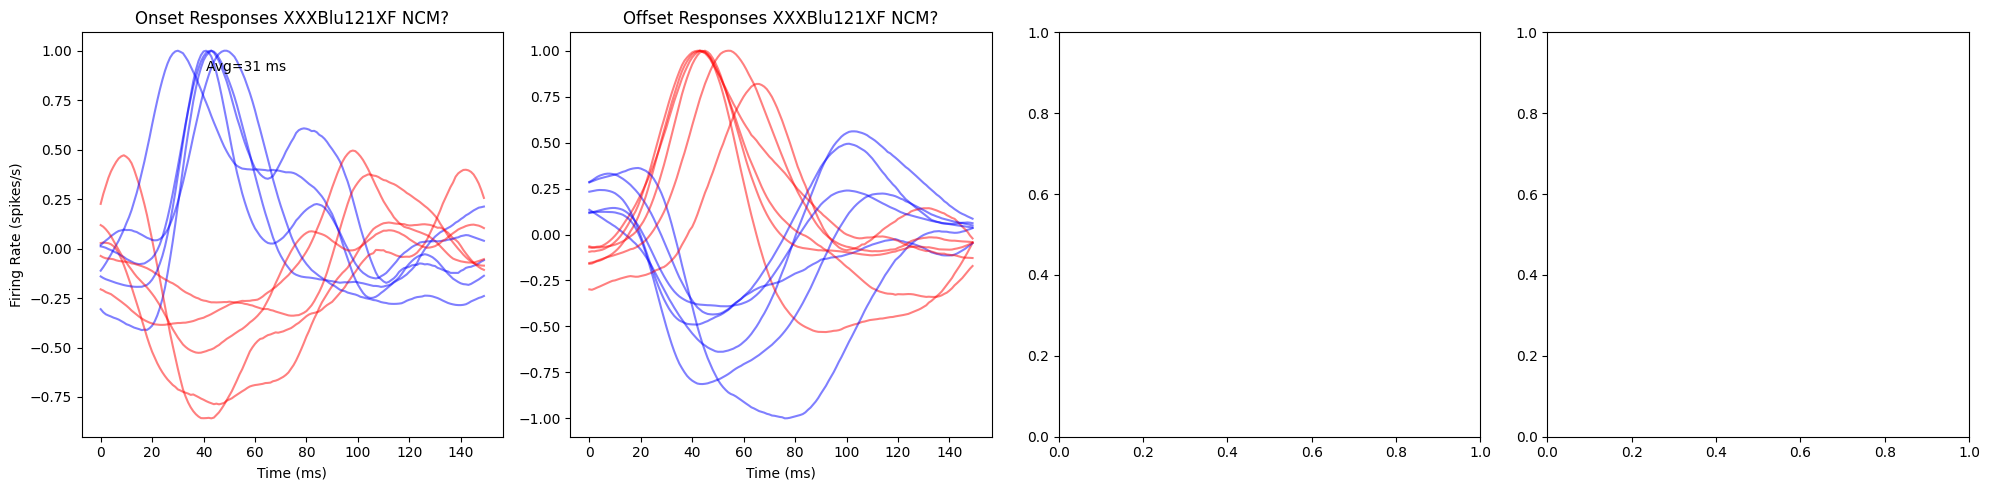

-------------------------------XXXLbl116XF-----------------------------
Onset unit numbers:
Unit   19: 0.25
Unit   25: 0.26
Unit 1029: 0.39
Unit 1031: 0.38
Unit 1035: 0.31
Unit 1036: 0.52
Unit 1038: 0.39
Unit 1040: 0.45
Offset unit numbers:
Other seg unit numbers:
Unit    4: 0.29


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

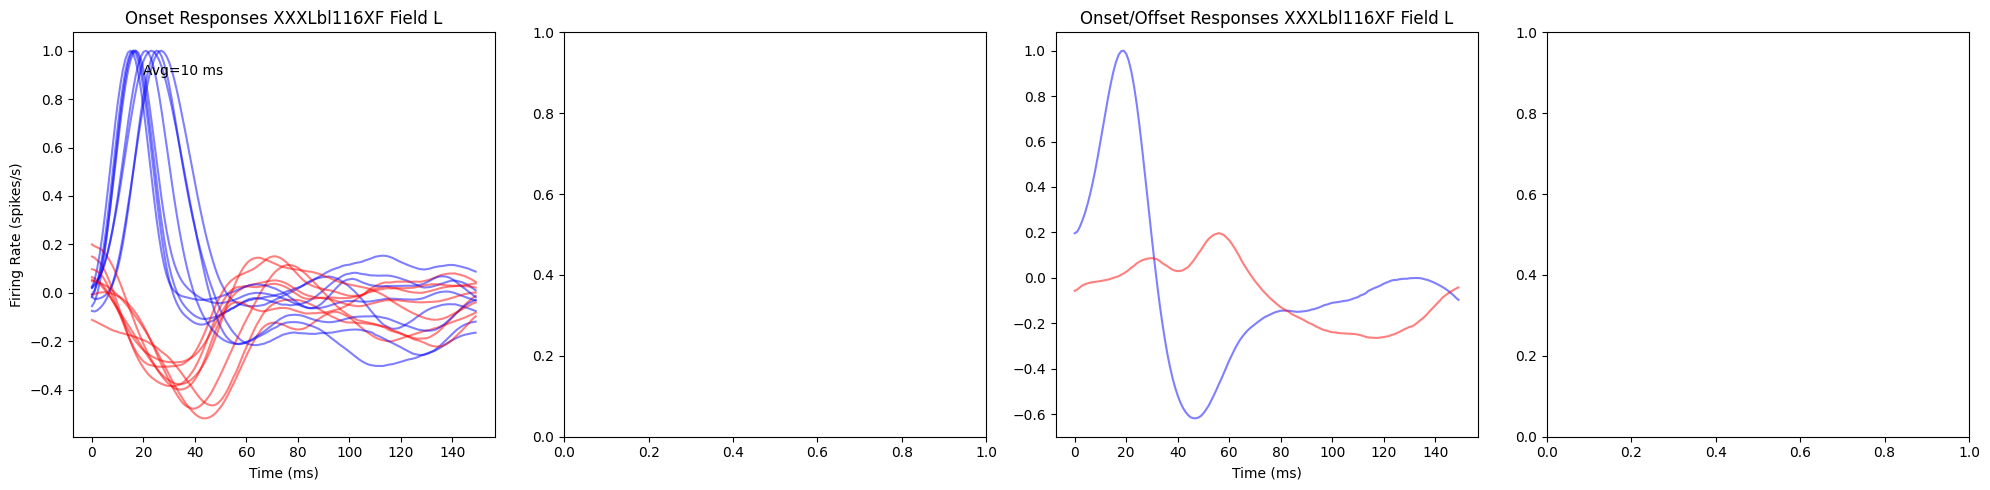

-------------------------------XXXLbl121XM-----------------------------
Onset unit numbers:
Unit 1118: 0.27
Unit 1120: 0.39
Unit 1125: 0.39
Unit 1140: 0.45
Unit 1169: 0.28
Unit 1501: 0.37
Unit 1502: 0.41
Offset unit numbers:
Unit 1127: 0.46
Unit 1139: 0.45
Unit 1144: 0.54
Unit 1147: 0.34
Unit 1152: 0.32
Unit 1159: 0.27
Unit 1165: 0.42
Other seg unit numbers:


/var/folders/zn/qkxxn59x2712k0l7j64f7ry40000gn/T/ipykernel_97550/2936950203.py:42: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  dataFrame  = pkl.load(infile)
/Users/frederictheunissen/opt/anaconda3/envs/spikesort/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 0.24.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_p

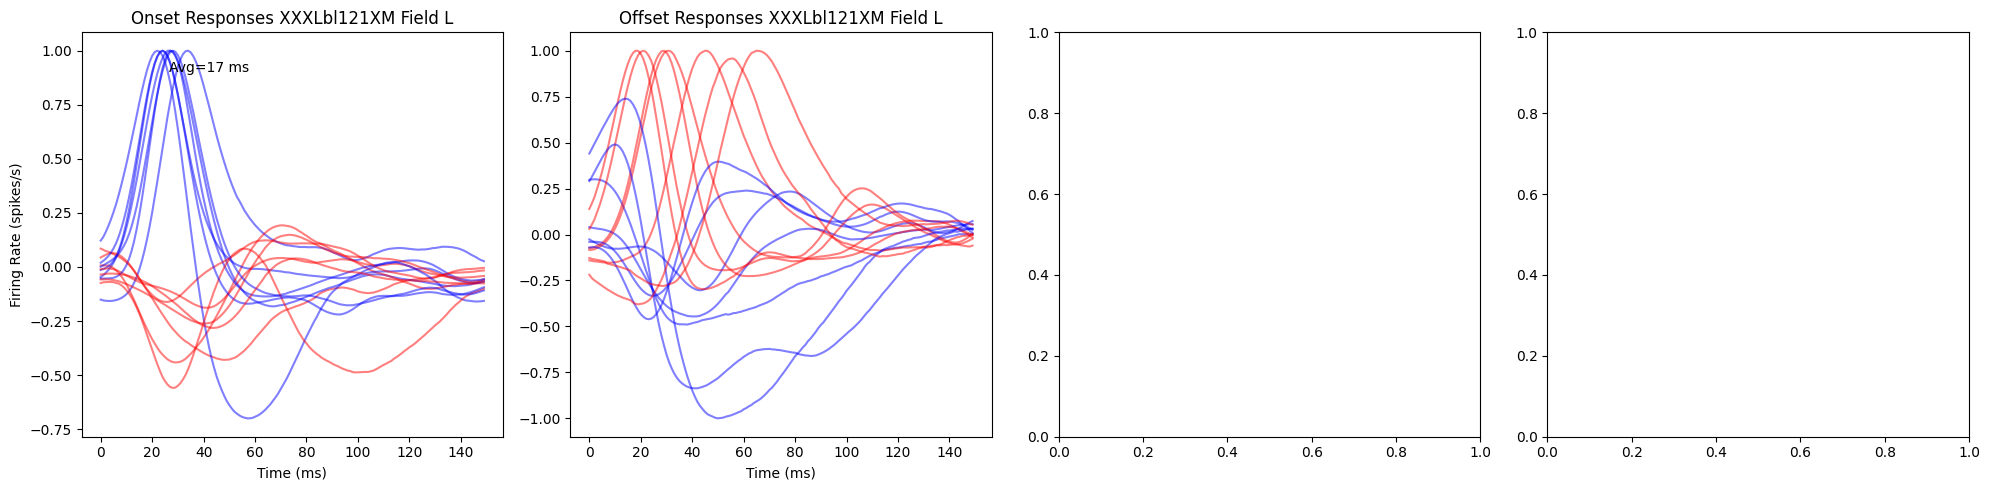

Number of Onset units: 81 (73.0 %)
	 Number of Onset units in NCM: 26 (59.1 %)

Number of Offset units: 16 (14.4 %)
	 Number of Offset units in NCM: 7 (15.9 %)
Number of Onset/Offset units: 14 (12.6 %)
	 Number of Onset/Offset units in NCM: 11 (78.6 %)
Number of Inhibitory units: 0 (0.0 %)
	 Number of Inhibitory units in NCM: 0 (0.0 %)


In [32]:
# Let's plot the onset and offset responses of all seg units

j = 0
nPoints =  150
t = np.arange(nPoints) 
nOnset = 0
nOffset = 0
nOnsetOffset = 0
nInhibitory = 0
nOnsetNCM = 0
nOffsetNCM = 0
nOnsetOffsetNCM = 0
nInhibitoryNCM = 0
nOnsetL = 0
nOffsetL = 0
nOnsetOffsetL = 0
nInhibitoryL = 0
onsetNCM = []
offsetNCM = []
onsetL = []
offsetL = []
onset_peaksNCM = []
offset_peaksNCM = []
onset_peaksL = []
offset_peaksL = []

allBirds = np.unique(birds)

for bird in allBirds:
    print(f"-------------------------------{bird}-----------------------------")
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    onset_peaks = []
    offset_peaks = []
    onset_units = []
    offset_units = []
    otherseg_units = []
    for f in data_files:
        if bird in f:
            file_path = os.path.join(data_dir, f)

            with open(file_path, 'rb') as infile:
                dataFrame  = pkl.load(infile)
                for i, row in dataFrame.iterrows():
                    if not isnan(row['snr']):
                        # find the index of the row in the metadata dataframe that corresponds to this file
                        unit = int(row['unit'])
                        unit_id = row['unit_id']
                        nwb_file = row['nwb_file']
                        idx_list = np.argwhere((birds == bird) & (units == unit) & (unit_ids == unit_id) & (nwbFiles == nwb_file)).flatten()
                        if len(idx_list) > 1:
                            print(f"Warning: Multiple entries found for Bird {bird} File {nwb_file} Unit {unit} Unit ID {unit_id}: {idx_list}. Using the first entry.")
                        idx_row = idx_list[0]
                        if seg_idx[idx_row]:
                            learned_conv_kernel = row.segModel['weights'].reshape(2, nPoints)
                            b0 = row.segModel['b0']
                            # Find peak in first 10-70 ms of onset kernel
                            onset_peak_idx = np.argmax(np.abs(learned_conv_kernel[0][10:70]))
                            # Find peak in first 1070 ms of offset kernel
                            offset_peak_idx = np.argmax(np.abs(learned_conv_kernel[1][10:70]))
                            scale = np.max(np.abs(learned_conv_kernel))
                            if (learned_conv_kernel[0][onset_peak_idx] ) > 0 and (learned_conv_kernel[1][offset_peak_idx] ) <= 0:
                                cell_type = 'Onset'
                                nOnset += 1
                                ax = axs[0]
                                ax.plot(t, learned_conv_kernel[0]/scale, color = 'blue', label='Onset Response', alpha=0.5)
                                ax.plot(t, learned_conv_kernel[1]/scale, color = 'red', label='Offset Response', alpha=0.5)
                                ax.set_title(f'Onset Responses {bird} {birdRegions[bird]}')
                                ax.set_xlabel('Time (ms)')
                                ax.set_ylabel('Firing Rate (spikes/s)')
                                onset_peaks.append(onset_peak_idx)
                                offset_peaks.append(offset_peak_idx)
                                onset_units.append(idx_row)
                                if brain_areas[idx_row] == 'NCM':
                                    onsetNCM.append(learned_conv_kernel[0]/scale)
                                    offsetNCM.append(learned_conv_kernel[1]/scale)
                                    onset_peaksNCM.append(onset_peak_idx)
                                    offset_peaksNCM.append(offset_peak_idx)
                                    nOnsetNCM += 1
                                else:
                                    onsetL.append(learned_conv_kernel[0]/scale)
                                    offsetL.append(learned_conv_kernel[1]/scale)
                                    onset_peaksL.append(onset_peak_idx)
                                    offset_peaksL.append(offset_peak_idx)
                                    nOnsetL += 1
                                # ax.legend()
                            elif (learned_conv_kernel[0][onset_peak_idx] ) <= 0 and (learned_conv_kernel[1][offset_peak_idx]) > 0:
                                cell_type = 'Offset'
                                offset_units.append(idx_row)
                                nOffset += 1
                                ax = axs[1]
                                ax.plot(t, learned_conv_kernel[0]/scale, color = 'blue', label='Onset Response', alpha=0.5)
                                ax.plot(t, learned_conv_kernel[1]/scale, color = 'red', label='Offset Response', alpha=0.5)
                                ax.set_title(f'Offset Responses {bird} {birdRegions[bird]}')
                                ax.set_xlabel('Time (ms)')
                                if brain_areas[idx_row] == 'NCM':
                                    nOffsetNCM += 1
                                else:
                                    nOffsetL += 1
                                # ax.legend()
                            elif (learned_conv_kernel[0][onset_peak_idx] ) > 0 and (learned_conv_kernel[1][offset_peak_idx]) > 0:
                                cell_type = 'Onset/Offset'
                                otherseg_units.append(idx_row)
                                nOnsetOffset += 1   
                                ax = axs[2]
                                ax.plot(t, learned_conv_kernel[0]/scale, color = 'blue', label='Onset Response', alpha=0.5)
                                ax.plot(t, learned_conv_kernel[1]/scale, color = 'red', label='Offset Response', alpha=0.5)
                                ax.set_title(f'Onset/Offset Responses {bird} {birdRegions[bird]}')
                                ax.set_xlabel('Time (ms)')
                                if brain_areas[idx_row] == 'NCM':
                                    nOnsetOffsetNCM += 1
                                else:
                                    nOnsetOffsetL += 1
                                # ax.legend()
                            else:
                                cell_type = 'Inhibitory'
                                otherseg_units.append(idx_row)
                                nInhibitory += 1
                                ax = axs[3]
                                ax.plot(t, learned_conv_kernel[0]/scale, color = 'blue', label='Onset Response', alpha=0.5)
                                ax.plot(t, learned_conv_kernel[1]/scale, color = 'red', label='Offset Response', alpha=0.5)
                                ax.set_title(f'Inhibitory Responses {bird} {birdRegions[bird]}')
                                ax.set_xlabel('Time (ms)')
                                if brain_areas[idx_row] == 'NCM':
                                    nInhibitoryNCM += 1
                                else:
                                    nInhibitoryL += 1
                                # ax.legend()
    print("Onset unit numbers:")
    printData = [(ind, r2) for ind, r2 in zip(onset_units, r2Segs[onset_units]/r2Ceils[onset_units])]
    for ind, r2 in printData:
        print(f"Unit {ind:4d}: {r2:.2f}")
    print("Offset unit numbers:")
    printData = [(ind, r2) for ind, r2 in zip(offset_units, r2Segs[offset_units]/r2Ceils[offset_units])]
    for ind, r2 in printData:
        print(f"Unit {ind:4d}: {r2:.2f}")
    print("Other seg unit numbers:")
    printData = [(ind, r2) for ind, r2 in zip(otherseg_units, r2Segs[otherseg_units]/r2Ceils[otherseg_units])]
    for ind, r2 in printData:
        print(f"Unit {ind:4d}: {r2:.2f}")

    if len(onset_peaks) > 0:
        peakTime = np.mean(onset_peaks)
        axs[0].text(peakTime+10 , 0.9, f'Avg={peakTime:.0f} ms', fontsize=10)
    plt.tight_layout()
    plt.show()




print(f"Number of Onset units: {nOnset} ({100.0*nOnset/np.sum(seg_idx):.1f} %)")
print(f"\t Number of Onset units in NCM: {nOnsetNCM} ({100.0*nOnsetNCM/nseg_NCM:.1f} %)")
print(f"")
print(f"Number of Offset units: {nOffset} ({100.0*nOffset/np.sum(seg_idx):.1f} %)")
print(f"\t Number of Offset units in NCM: {nOffsetNCM} ({100.0*nOffsetNCM/nseg_NCM:.1f} %)")
print(f"Number of Onset/Offset units: {nOnsetOffset} ({100.0*nOnsetOffset/np.sum(seg_idx):.1f} %)")
print(f"\t Number of Onset/Offset units in NCM: {nOnsetOffsetNCM} ({100.0*nOnsetOffsetNCM/nOnsetOffset:.1f} %)")
print(f"Number of Inhibitory units: {nInhibitory} ({100.0*nInhibitory/np.sum(seg_idx):.1f} %)")
print(f"\t Number of Inhibitory units in NCM: {nInhibitoryNCM} ({100.0*nInhibitoryNCM/nseg_NCM:.1f} %)")

In [33]:
# Test for difference in onset peak times between L and NCM
print("Testing for difference in onset peak times between L and NCM")
onset_peaksNCM = np.array(onset_peaksNCM)
onset_peaksL = np.array(onset_peaksL)
meanOnsetPeakNCM = np.mean(onset_peaksNCM)
semOnsetPeakNCM = np.std(onset_peaksNCM)/np.sqrt(len(onset_peaksNCM))
meanOnsetPeakL = np.mean(onset_peaksL)
semOnsetPeakL = np.std(onset_peaksL)/np.sqrt(len(onset_peaksL))
print(f"Mean onset peak time for NCM: {meanOnsetPeakNCM:.2f} ms +- {semOnsetPeakNCM:.3f}")
print(f"Mean onset peak time for L: {meanOnsetPeakL:.2f} ms +- {semOnsetPeakL:.3f}")
t_stat, p_value = stats.ttest_ind(onset_peaksNCM, onset_peaksL, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.3g}")

# Test for difference in offset peak times between L and NCM
print("Testing for difference in offset peak times between L and NCM")
offset_peaksNCM = np.array(offset_peaksNCM)
offset_peaksL = np.array(offset_peaksL)
meanOffsetPeakNCM = np.mean(offset_peaksNCM)        
semOffsetPeakNCM = np.std(offset_peaksNCM)/np.sqrt(len(offset_peaksNCM))
meanOffsetPeakL = np.mean(offset_peaksL)
semOffsetPeakL = np.std(offset_peaksL)/np.sqrt(len(offset_peaksL))
print(f"Mean offset peak time for NCM: {meanOffsetPeakNCM:.2f} ms +- {semOffsetPeakNCM:.3f}")
print(f"Mean offset peak time for L: {meanOffsetPeakL:.2f} ms +- {semOffsetPeakL:.3f}")
t_stat, p_value = stats.ttest_ind(offset_peaksNCM, offset_peaksL, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, p-value: {p_value:.3g}")

Testing for difference in onset peak times between L and NCM
Mean onset peak time for NCM: 31.00 ms +- 2.767
Mean onset peak time for L: 14.27 ms +- 0.649
T-statistic: 5.774, p-value: 3.49e-06
Testing for difference in offset peak times between L and NCM
Mean offset peak time for NCM: 33.69 ms +- 2.529
Mean offset peak time for L: 22.67 ms +- 0.993
T-statistic: 3.982, p-value: 0.000357


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


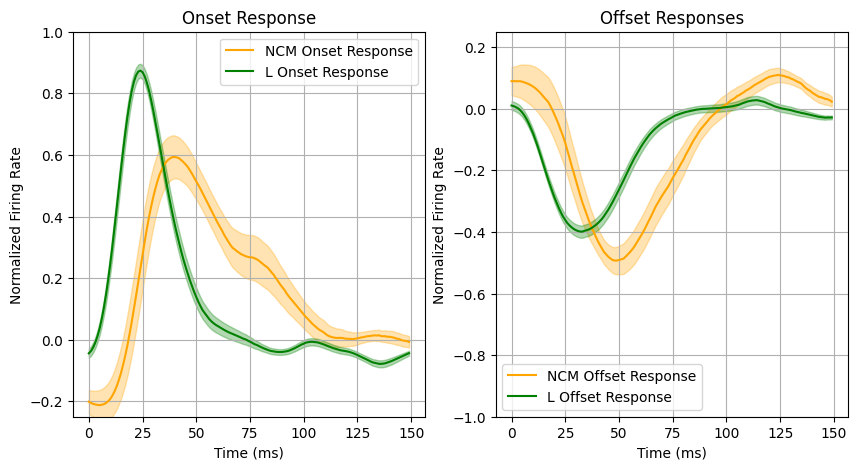

In [34]:
# Plot the average onset and offset responses for NCM vs L
plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
if len(onsetNCM) > 0:
    mean_onsetNCM = np.mean(onsetNCM, axis=0)
    sem_onsetNCM = np.std(onsetNCM, axis=0)/np.sqrt(len(onsetNCM))
    plt.plot(t, mean_onsetNCM, color='orange', label='NCM Onset Response')
    plt.fill_between(t, mean_onsetNCM - sem_onsetNCM, mean_onsetNCM + sem_onsetNCM, color='orange', alpha=0.3)
if len(onsetL) > 0:
    mean_onsetL = np.mean(onsetL, axis=0)
    sem_onsetL = np.std(onsetL, axis=0)/np.sqrt(len(onsetL))
    plt.plot(t, mean_onsetL, color='green', label='L Onset Response')
    plt.fill_between(t, mean_onsetL - sem_onsetL, mean_onsetL + sem_onsetL, color='green', alpha=0.3)
plt.title('Onset Response')
plt.xlabel('Time (ms)')
plt.ylabel('Normalized Firing Rate')
plt.ylim((-0.25, 1.0))
plt.legend()
plt.grid(True)      
plt.subplot(1,2,2)
if len(offsetNCM) > 0:
    mean_offsetNCM = np.mean(offsetNCM, axis=0)
    sem_offsetNCM = np.std(offsetNCM, axis=0)/np.sqrt(len(offsetNCM))
    plt.plot(t, mean_offsetNCM, color='orange', label='NCM Offset Response')
    plt.fill_between(t, mean_offsetNCM - sem_offsetNCM, mean_offsetNCM + sem_offsetNCM, color='orange', alpha=0.3)
if len(offsetL) > 0:
    mean_offsetL = np.mean(offsetL, axis=0)
    sem_offsetL = np.std(offsetL, axis=0)/np.sqrt(len(offsetL))
    plt.plot(t, mean_offsetL, color='green', label='L Offset Response')
    plt.fill_between(t, mean_offsetL - sem_offsetL, mean_offsetL + sem_offsetL, color='green', alpha=0.3)
plt.title('Offset Responses')
plt.xlabel('Time (ms)')
plt.ylabel('Normalized Firing Rate')
plt.ylim((-1.0, 0.25))
plt.grid(True)
plt.legend()

plt.savefig('/Users/frederictheunissen/Desktop/OnsetOffsetResponses.eps', dpi=300)
plt.show()